# **Sensor Component Failure Prediction**

#### **Objective: Detect APS-related failures while minimizing the total cost of misclassification.**

### **Air Pressure Sensor Fault Detection**

### 1. Problem Statement

### Overview

The system in focus is the **Air Pressure System (APS)**, which generates pressurized air used for various functions in a truck, such as:

- Braking
- Gear changes
- Other pneumatic functions

The objective of this project is to develop a machine learning model that can predict whether a truck has a **failure related to the Air Pressure System (APS)**.

### Dataset

The dataset consists of **sensor data collected from trucks**.

The target variable has two classes:

- **Positive Class:** Failure related to a component of the Air Pressure System (APS)
- **Negative Class:** Failure related to a component that is **not related to the Air Pressure System**

In other words:

| Class | Meaning |
|---|---|
| Positive (1) | APS-related component failure |
| Negative (0) | Failure not related to APS |

---

## 2. Business Objective

The primary objective is to **reduce unnecessary repair and inspection costs** while minimizing the risk of missing a truck with an APS-related failure.

A wrong prediction can result in two different types of costs:

1. **False Positive:** A truck is predicted to have an APS failure when it actually does not.
   - This results in an unnecessary inspection or repair by a mechanic.
   - Cost = **10**

2. **False Negative:** A truck actually has an APS failure, but the model predicts that it does not.
   - This failure may be missed and could potentially lead to a truck breakdown.
   - Cost = **500**

Therefore, a **false negative is 50 times more expensive than a false positive**.

---

## 3. Cost Matrix

The cost associated with each prediction can be represented as follows:

| Actual Class | Predicted Positive | Predicted Negative |
|---|---:|---:|
| **Positive** | 0 | **500 (False Negative)** |
| **Negative** | **10 (False Positive)** | 0 |

Where:

- **Cost 1 = 10:** Cost of an unnecessary inspection/repair.
- **Cost 2 = 500:** Cost of missing an actual faulty truck.

---

## 4. Total Cost

The total cost of the prediction model is calculated based on the number of false positives and false negatives.

### Formula

```text
Total Cost = (Cost 1 × Number of False Positives)
           + (Cost 2 × Number of False Negatives)

### **2) Import required libraries**

In [26]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Data preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder
)

# Data sampling and imputation
from sklearn.utils import resample
from sklearn.impute import SimpleImputer, KNNImputer

# Pipeline and column transformation
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Gradient boosting models
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Model selection and hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate
)

# Statistical functions
from statistics import mean, median, mode

# Warnings
import warnings

warnings.filterwarnings("ignore")
# Remove the display limits for rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display plots inline in Jupyter Notebook
%matplotlib inline

In [27]:
# Load csv file
df = pd.read_csv(r'https://raw.githubusercontent.com/avnyadav/sensor-fault-detection/main/aps_failure_training_set1.csv',na_values="na")

### **Phase 1: Data Understanding**

In [28]:
# Explore the dataset
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,0.0,182.0,NaN,0.0,0.0,0.0,0.0,0.0,11804.0,684444.0,326536.0,31586.0,0.0,0.0,0.0,2658638.0,14346.0,0.0,0.0,29384.0,46356.0,5566182.0,4426834.0,1571480.0,1120644.0,2.0,0.0,0.0,0.0,1368.0,862.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94188.0,960182.0,0.0,250.0,16.0,32.0,146.0,126.0,951126.0,91162.0,11512.0,0.0,0.0,702994.0,186172.0,69282.0,36640.0,20698.0,17720.0,18586.0,2278.0,0.0,0.0,7167172.0,692.0,152.0,1690.0,294.0,2658638.0,126990.0,355360.0,1215418.0,263620.0,263960.0,253220.0,260500.0,270840.0,NaN,NaN,NaN,255200.0,153203.49,7167172.0,7167172.0,1065896.0,2169.0,415352.0,108024.0,1114900.0,6785612.0,1209600.0,0.0,NaN,NaN,NaN,14779408.32,5602235.52,6587273.28,0.0,8.0,0.0,0.0,32854.0,113024.0,413450.0,341800.0,110462.0,40426.0,2354.0,0.0,NaN,0.0,7167172.0,0.0,556.0,62.0,11606.0,370336.0,119892.0,399936.0,149156.0,2826.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16910.0,218.0,0.0,0.0,55760.0,1433920.0,0.0,0.0,0.0,0.0,51558.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.90,166.0,512878.0,293880.0,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,NaN,2926.0,NaN,0.0,0.0,0.0,0.0,222.0,323436.0,2999280.0,20657518.0,12530224.0,913700.0,12670.0,0.0,18489312.0,19038.0,0.0,NaN,117902.0,203782.0,32633282.0,28658284.0,5348896.0,3667892.0,0.0,0.0,0.0,0.0,24514.0,1858.0,2273870.0,2608460.0,1424956.0,1607946.0,1409344.0,2051868.0,2227058.0,8113476.0,15720072.0,0.0,28828.0,33264.0,47402.0,627172.0,26128758.0,10570790.0,804.0,22.0,8.0,2.0,12630142.0,9040546.0,7110184.0,4970218.0,2616558.0,886208.0,160242.0,22100.0,842.0,10.0,38100406.0,632.0,1686.0,2018.0,684.0,18489312.0,447850.0,2507262.0,2827898.0,366980.0,314860.0,176220.0,232680.0,162300.0,189300.0,187600.0,189400.0,190440.0,453236.92,38100374.0,38100374.0,37843756.0,189372.0,8436120.0,NaN,565520.0,37437050.0,1209600.0,0.0,NaN,NaN,NaN,33480473.28,0.00,3935856.96,NaN,NaN,0.0,24598.0,523608.0,11350372.0,19808010.0,5225236.0,439104.0,59042.0,6950.0,130.0,NaN,42.0,38100374.0,NaN,16738.0,3392.0,1441482.0,1867216.0,1513156.0,21289878.0,11184234.0,120904.0,50.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18132.0,2442.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,260830.0,169964.0,26740.0,73289586.0,16623244.0,1056682.0,155406.0,93686740.0,28423762.0,7966.0,382610.0,0.0,0.0,432739640.0,NaN,NaN,4079752.0,13176956.0,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,NaN,1594.0,1052.0,0.0,0.0,0.0,244.0,178226.0,1249396.0,3813464.0,4876588.0,1202196.0,80186.0,5892.0,1154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,6488.0,1414.0,0.0,0.0,0.0,0.0,0.0,0.0,605072.0,8238656.0,2563618.0,0.0,8592.0,7120.0,15282.0,23666.0,1102276.0,10250396.0,14.0,0.0,0.0,0.0,7118800.0,2398182.0,787330.0,396066.0,243178.0,157416.0,110850.0,103378.0,72600.0,19546.0,NaN,366.0,234

In [29]:
# check rows and columns of the dataset
df.shape

(36188, 171)

In [30]:
# Check for unique values in the target column
df['class'].value_counts()

class
neg    35188
pos     1000
Name: count, dtype: int64

In [31]:
# Check for missing values in the dataset
df.isnull().sum()

class         0
aa_000        0
ab_000    27896
ac_000     2141
ad_000     9200
ae_000     1587
af_000     1587
ag_000      379
ag_001      379
ag_002      379
ag_003      379
ag_004      379
ag_005      379
ag_006      379
ag_007      379
ag_008      379
ag_009      379
ah_000      382
ai_000      375
aj_000      375
ak_000     2783
al_000      382
am_0        375
an_000      382
ao_000      345
ap_000      382
aq_000      345
ar_000     1729
as_000      375
at_000      375
au_000      375
av_000     1588
ax_000     1589
ay_000      379
ay_001      379
ay_002      379
ay_003      379
ay_004      379
ay_005      379
ay_006      379
ay_007      379
ay_008      379
ay_009      379
az_000      379
az_001      379
az_002      379
az_003      379
az_004      379
az_005      379
az_006      379
az_007      379
az_008      379
az_009      379
ba_000      386
ba_001      386
ba_002      386
ba_003      386
ba_004      386
ba_005      386
ba_006      386
ba_007      386
ba_008      386
ba_009  

In [32]:
print(df.info())
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 36188 entries, 0 to 36187
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 47.2 MB
None
class         str
aa_000      int64
ab_000    float64
ac_000    float64
ad_000    float64
ae_000    float64
af_000    float64
ag_000    float64
ag_001    float64
ag_002    float64
ag_003    float64
ag_004    float64
ag_005    float64
ag_006    float64
ag_007    float64
ag_008    float64
ag_009    float64
ah_000    float64
ai_000    float64
aj_000    float64
ak_000    float64
al_000    float64
am_0      float64
an_000    float64
ao_000    float64
ap_000    float64
aq_000    float64
ar_000    float64
as_000    float64
at_000    float64
au_000    float64
av_000    float64
ax_000    float64
ay_000    float64
ay_001    float64
ay_002    float64
ay_003    float64
ay_004    float64
ay_005    float64
ay_006    float64
ay_007    float64
ay_008    float64
ay_009    float64
az_000    float64
az_001    float64
az_002    float64
az_

In [33]:
# Define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

# numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = [feature for feature in df.columns if (df[feature].dtype == 'O')| (df[feature].dtype == 'str')]
# categorical_columns = df.select_dtypes(include=['object']).columns

# Print the numerical and categorical columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 171 numerical features : ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000',

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
aa_000,36188.0,6.591016e+04,1.641238e+05,0.0,866.000,31026.00,50068.500,2.746564e+06
ab_000,8292.0,7.117704e-01,3.054033e+00,0.0,0.000,0.00,0.000,1.000000e+02
ac_000,34047.0,3.535223e+08,7.926486e+08,0.0,16.000,152.00,964.000,2.130707e+09
ad_000,26988.0,3.185447e+05,5.225398e+07,0.0,24.000,128.00,432.000,8.584298e+09
ae_000,34601.0,7.234300e+00,1.864373e+02,0.0,0.000,0.00,0.000,2.105000e+04
af_000,34601.0,1.160654e+01,2.344054e+02,0.0,0.000,0.00,0.000,2.007000e+04
ag_000,35809.0,1.952347e+02,1.852862e+04,0.0,0.000,0.00,0.000,3.376892e+06
ag_001,35809.0,1.508277e+03,4.371360e+04,0.0,0.000,0.00,0.000,4.109372e+06
ag_002,35809.0,1.250718e+04,1.801543e+05,0.0,0.000,0.00,0.000,1.055286e+07
ag_003,35809.0,1.156928e+05,8.853380e+05,0.0,0.000,0.00,0.000,2.904730e+07


In [35]:
df["class"].value_counts()

class
neg    35188
pos     1000
Name: count, dtype: int64

In [36]:
df["class"].value_counts(normalize=True) * 100

class
neg    97.236653
pos     2.763347
Name: proportion, dtype: float64

In [37]:
df.isna().sum().sort_values(ascending=False)

br_000    29461
bq_000    29132
bp_000    28514
cr_000    27896
ab_000    27896
bo_000    27696
bn_000    26331
bm_000    23710
bl_000    16335
bk_000    13823
ad_000     9200
cg_000     9200
ch_000     9200
cf_000     9200
co_000     9200
cx_000     8522
cz_000     8522
cy_000     8522
dc_000     8522
db_000     8522
cv_000     8522
ct_000     8522
da_000     8522
cu_000     8522
ec_00      6209
cm_000     5981
cl_000     5765
ed_000     5765
ak_000     2783
ca_000     2749
dm_000     2546
dl_000     2545
dg_000     2545
df_000     2545
dh_000     2545
eb_000     2544
dj_000     2544
dk_000     2544
di_000     2543
ac_000     2141
bx_000     1895
cc_000     1894
bd_000     1732
dt_000     1732
dp_000     1732
ds_000     1732
dq_000     1732
dr_000     1731
dv_000     1731
du_000     1731
bc_000     1731
cp_000     1730
de_000     1730
do_000     1730
ef_000     1730
dy_000     1730
eg_000     1729
ar_000     1729
dx_000     1729
dz_000     1729
ea_000     1729
bz_000     1729
dd_000  

In [38]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

br_000    81.410965
bq_000    80.501824
bp_000    78.794075
cr_000    77.086327
ab_000    77.086327
bo_000    76.533658
bn_000    72.761689
bm_000    65.518957
bl_000    45.139273
bk_000    38.197745
ad_000    25.422792
cg_000    25.422792
ch_000    25.422792
cf_000    25.422792
co_000    25.422792
cx_000    23.549243
cz_000    23.549243
cy_000    23.549243
dc_000    23.549243
db_000    23.549243
cv_000    23.549243
ct_000    23.549243
da_000    23.549243
cu_000    23.549243
ec_00     17.157621
cm_000    16.527578
cl_000    15.930695
ed_000    15.930695
ak_000     7.690395
ca_000     7.596441
dm_000     7.035481
dl_000     7.032718
dg_000     7.032718
df_000     7.032718
dh_000     7.032718
eb_000     7.029955
dj_000     7.029955
dk_000     7.029955
di_000     7.027191
ac_000     5.916326
bx_000     5.236543
cc_000     5.233779
bd_000     4.786117
dt_000     4.786117
dp_000     4.786117
ds_000     4.786117
dq_000     4.786117
dr_000     4.783354
dv_000     4.783354
du_000     4.783354


In [39]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nTarget Distribution:")
print(df["class"].value_counts())

print("\nTarget Distribution (%):")
print(df["class"].value_counts(normalize=True) * 100)

print("\nMissing Values:")
print(df.isna().sum().sort_values(ascending=False).head(20))


Shape: (36188, 171)

Columns:
['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'c

### **Missing Values Analysis**

In [59]:
missing_summary = pd.DataFrame({
    "Missing_Counts": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100)
        }).sort_values("Missing_Percentage", ascending=False)
missing_summary

,Missing_Counts,Missing_Percentage
br_000,29461,81.410965
bq_000,29132,80.501824
bp_000,28514,78.794075
cr_000,27896,77.086327
ab_000,27896,77.086327
bo_000,27696,76.533658
bn_000,26331,72.761689
bm_000,23710,65.518957
bl_000,16335,45.139273
bk_000,13823,38.197745


In [60]:
# missing_summary = pd.DataFrame({
#     "Missing_Count": df.isna().sum(),
#     "Missing_Percentage": df.isna().mean() * 100
# })

# missing_summary = (
#     missing_summary
#     .sort_values("Missing_Percentage", ascending=False)
# )

# missing_summary

In [61]:
# Checking features with missing values greater than 50%, 75%, and 90%
print("Features with more than 50% missing values:",
      (missing_summary['Missing_Percentage'] > 50).sum())
print("Features with more than 75% missing values:",
      (missing_summary['Missing_Percentage'] > 75).sum())
print("Features with more than 90% missing values:",
      (missing_summary['Missing_Percentage'] > 90).sum())

Features with more than 50% missing values: 8
Features with more than 75% missing values: 6
Features with more than 90% missing values: 0


In [63]:
# Missing by class
missing_by_class = (
    df.groupby('class')
    .apply(lambda x: x.isna().mean() * 100)
    .T
)
missing_by_class['difference'] = (
    missing_by_class['pos'] - 
    missing_by_class['neg']
    )

missing_by_class =(
    missing_by_class
    .sort_values('difference', ascending=False)
    )
missing_by_class

class,neg,pos,difference
ak_000,6.397067,53.2,46.802933
ca_000,6.306127,53.0,46.693873
di_000,5.737752,52.4,46.662248
dk_000,5.740593,52.4,46.659407
eb_000,5.740593,52.4,46.659407
dj_000,5.740593,52.4,46.659407
dl_000,5.743435,52.4,46.656565
dg_000,5.743435,52.4,46.656565
df_000,5.743435,52.4,46.656565
dh_000,5.743435,52.4,46.656565


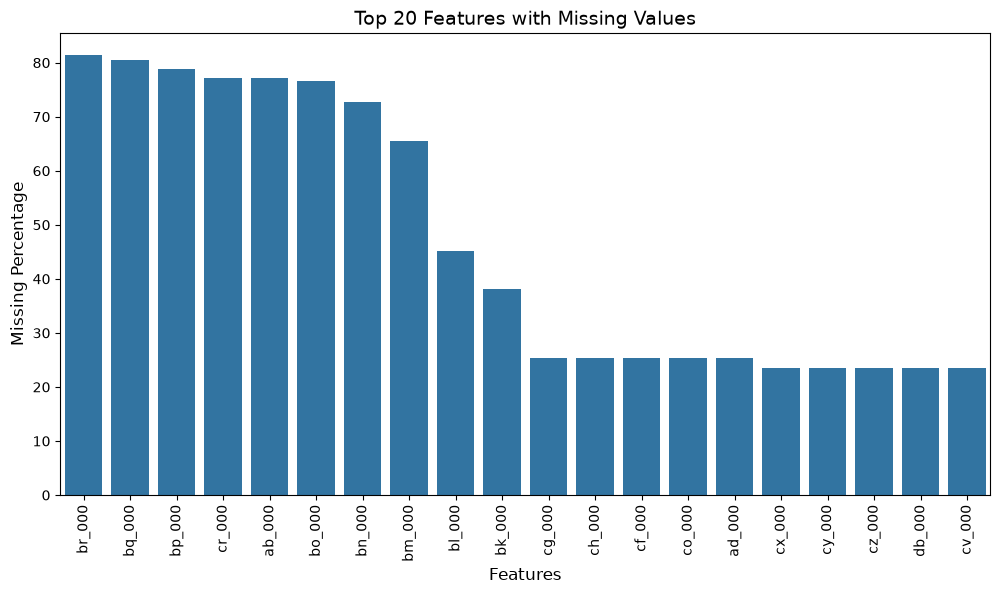

In [64]:
# Plotting the missing values for each feature
plt.figure(figsize=(12, 6))

sns.barplot(
    x = missing_summary.head(20).index,
    y = missing_summary.head(20)['Missing_Percentage']
)

plt.xlabel('Features', fontsize=12)
plt.ylabel('Missing Percentage', fontsize=12)
plt.title('Top 20 Features with Missing Values', fontsize=14)
plt.xticks(rotation=90)
plt.show()

### **Checking Duplicate Rows in Target Column**

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### **Checking Duplicate Rows in Data**

In [ ]:

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


### **Checking the distribution of the target variable**

In [68]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head())


class:
class
neg    35188
pos     1000
Name: count, dtype: int64


<Axes: xlabel='class'>

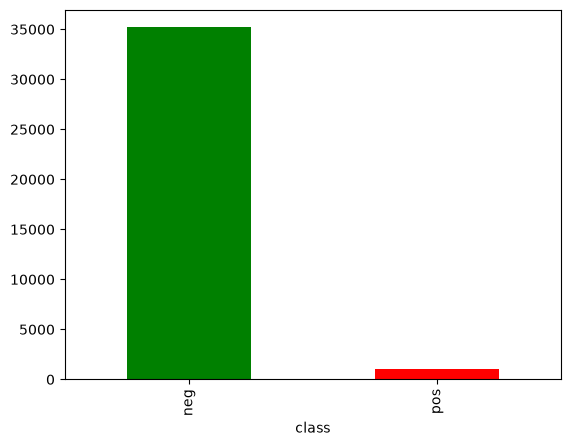

In [ ]:

df['class'].value_counts().plot(kind='bar', color=['green', 'red'])

In [49]:
# Number of unique values in each feature
feature_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
    "unique_values": df.nunique()
})
feature_summary.sort_values(
    "unique_values",
    ascending=True
)

,dtype,missing_count,missing_percentage,unique_values
cd_000,float64,402,1.110865,1
class,str,0,0.000000,2
ch_000,float64,9200,25.422792,2
as_000,float64,375,1.036255,14
ef_000,float64,1730,4.780590,21
ab_000,float64,27896,77.086327,23
au_000,float64,375,1.036255,39
dz_000,float64,1729,4.777827,41
eg_000,float64,1729,4.777827,42
cs_009,float64,378,1.044545,43


In [54]:
# Basic descriptive statistics
X.describe().T

,count,mean,std,min,25%,50%,75%,max
aa_000,36188.0,6.591016e+04,1.641238e+05,0.0,866.000,31026.00,50068.500,2.746564e+06
ab_000,8292.0,7.117704e-01,3.054033e+00,0.0,0.000,0.00,0.000,1.000000e+02
ac_000,34047.0,3.535223e+08,7.926486e+08,0.0,16.000,152.00,964.000,2.130707e+09
ad_000,26988.0,3.185447e+05,5.225398e+07,0.0,24.000,128.00,432.000,8.584298e+09
ae_000,34601.0,7.234300e+00,1.864373e+02,0.0,0.000,0.00,0.000,2.105000e+04
af_000,34601.0,1.160654e+01,2.344054e+02,0.0,0.000,0.00,0.000,2.007000e+04
ag_000,35809.0,1.952347e+02,1.852862e+04,0.0,0.000,0.00,0.000,3.376892e+06
ag_001,35809.0,1.508277e+03,4.371360e+04,0.0,0.000,0.00,0.000,4.109372e+06
ag_002,35809.0,1.250718e+04,1.801543e+05,0.0,0.000,0.00,0.000,1.055286e+07
ag_003,35809.0,1.156928e+05,8.853380e+05,0.0,0.000,0.00,0.000,2.904730e+07


### 1. Constant feature: `cd_000`

In [55]:
# Check for the constant features (features with only one unique value)
constant_features = [
    col for col in df.drop(columns=['class']).columns 
    if df[col].nunique(dropna=True) <= 1
        ]
print("Number of constant features:", len(constant_features))
print("Constant features:", constant_features)

Number of constant features: 1
Constant features: ['cd_000']


In [56]:
df['cd_000'].describe()

count      35786.0
mean     1209600.0
std            0.0
min      1209600.0
25%      1209600.0
50%      1209600.0
75%      1209600.0
max      1209600.0
Name: cd_000, dtype: float64

- Every non-missing value of cd_000 is exactly the same.

In [57]:
df.drop(columns = ['cd_000'], inplace=True)

- `cd_000` was removed because it is a constant feature with zero variance and therefore cannot contribute to classification.

In [69]:
# Check feature skewness
X = df.drop(columns=['class'])
skewness = X.skew(numeric_only=True)
print("Feature Skewness:")

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})
skewness_df

Feature Skewness:


,Feature,Skewness
0,aa_000,5.663207
1,ab_000,18.260282
2,ac_000,1.796188
3,ad_000,164.280247
4,ae_000,88.374590
5,af_000,53.155514
6,ag_000,170.704894
7,ag_001,60.197319
8,ag_002,29.824086
9,ag_003,14.452158


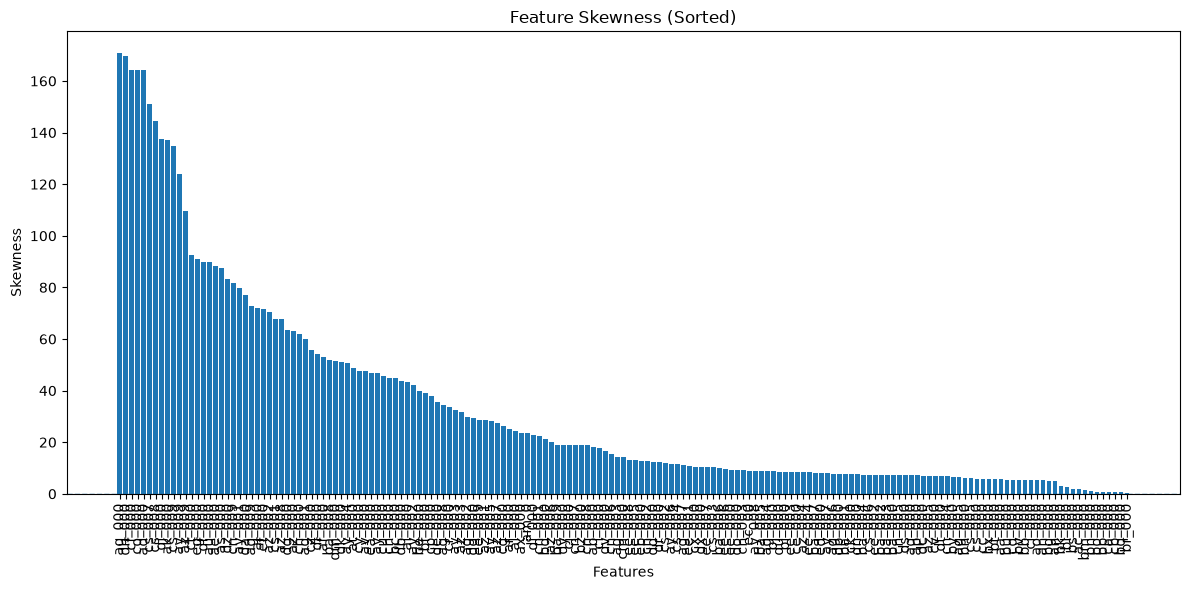

In [71]:
skewness_df = skewness_df.sort_values(
    by="Skewness",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    skewness_df["Feature"],
    skewness_df["Skewness"]
)

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("Feature Skewness (Sorted)")
plt.xlabel("Features")
plt.ylabel("Skewness")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

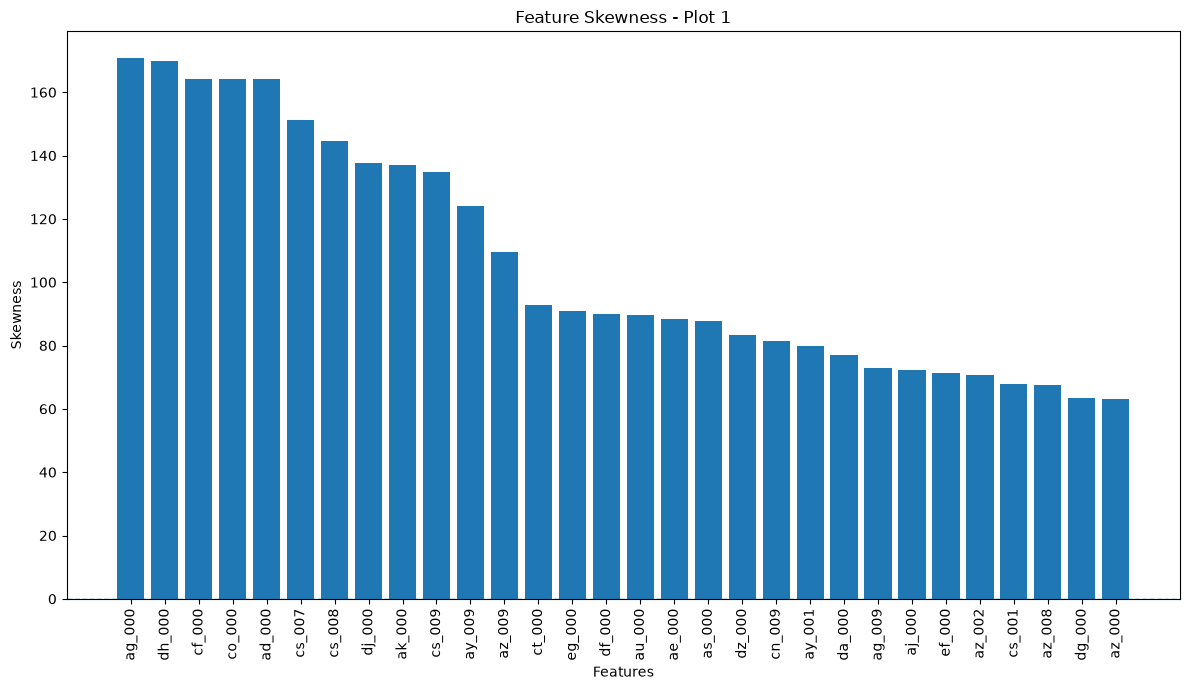

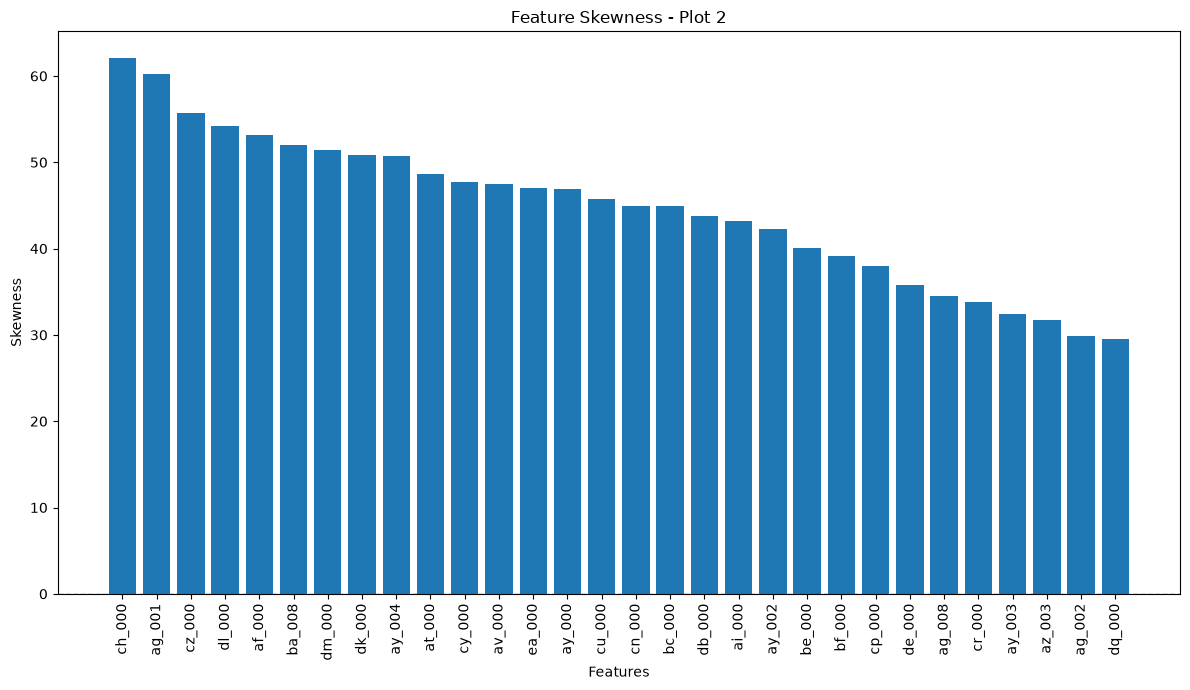

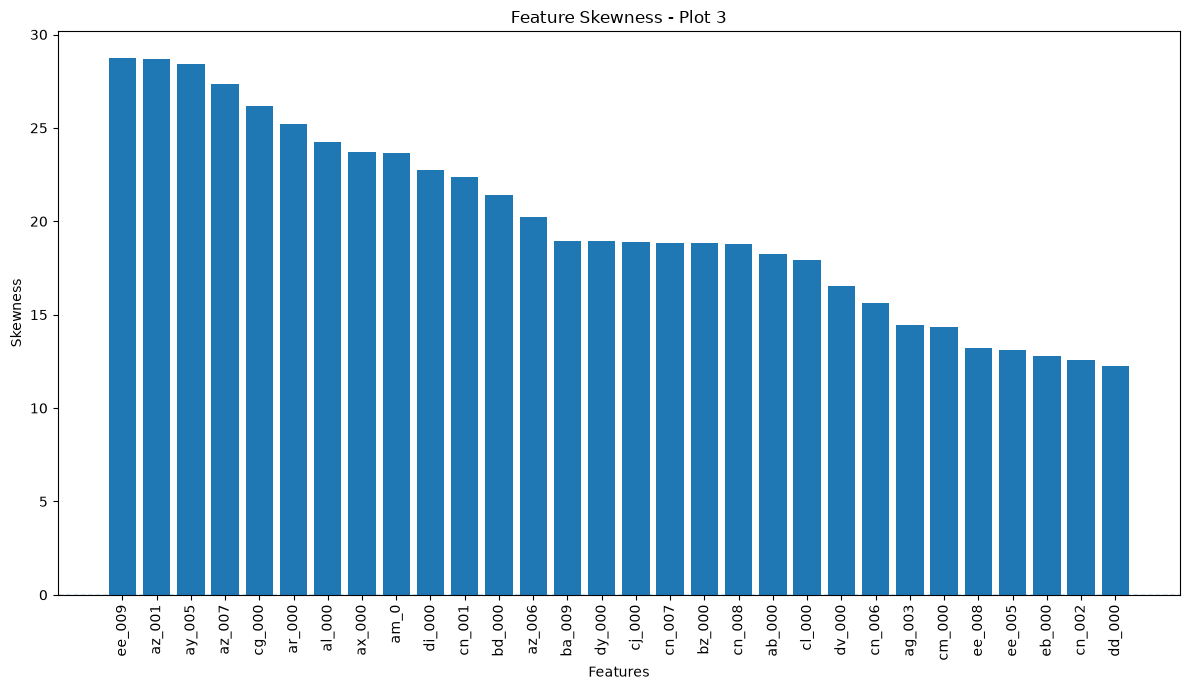

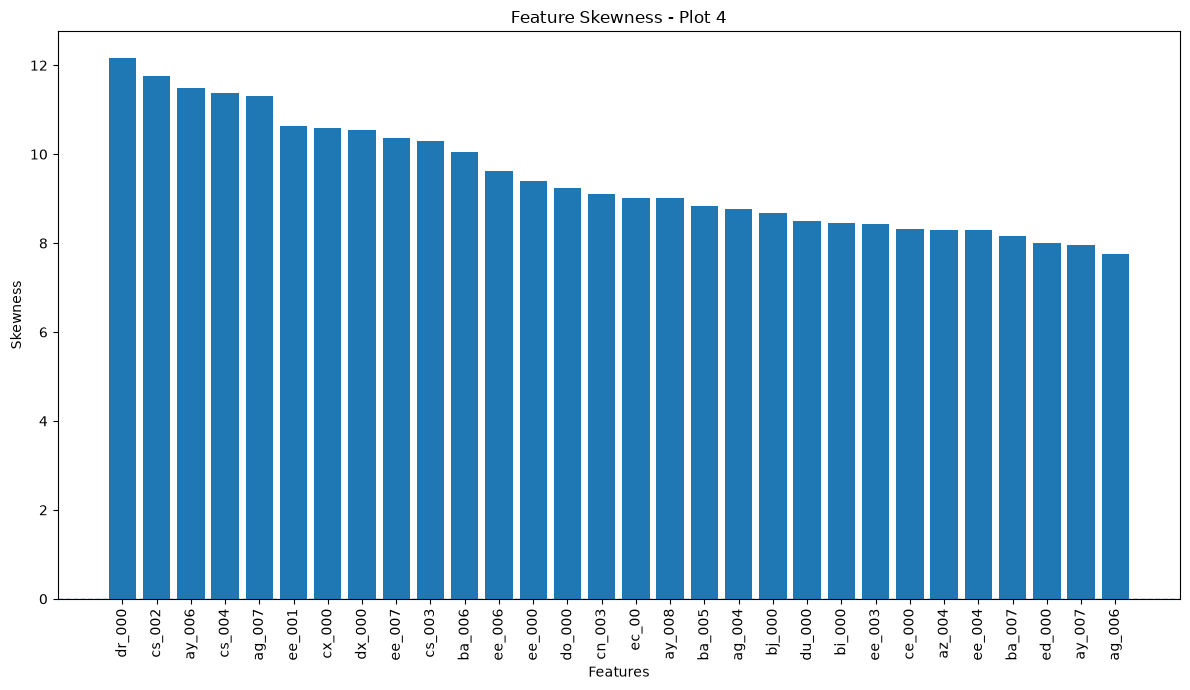

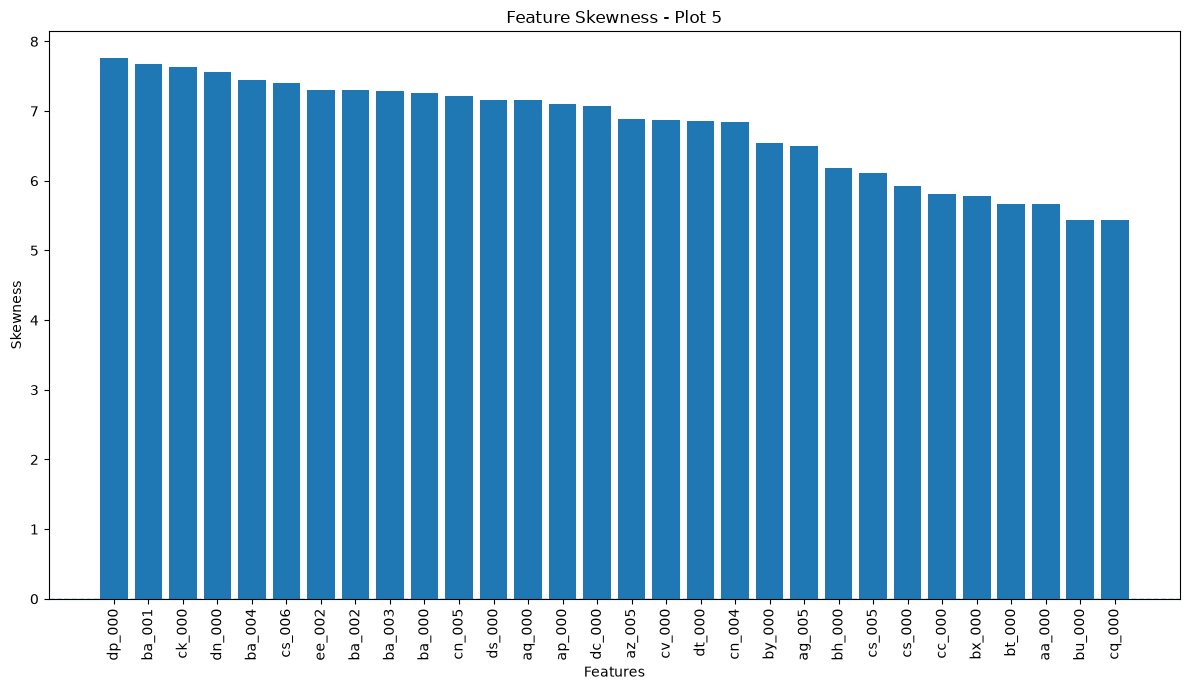

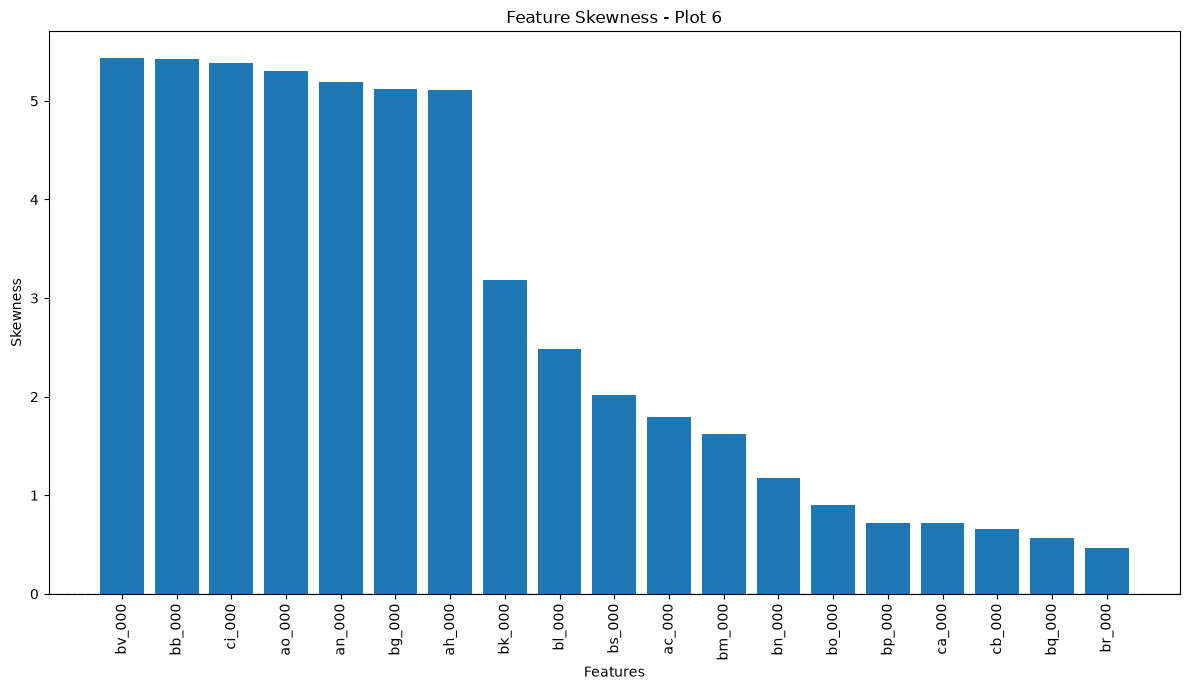

In [72]:
import matplotlib.pyplot as plt
import math

# Sort features by skewness
sorted_skewness = skewness_df.sort_values(
    by="Skewness",
    ascending=False
)

# Number of features per graph
features_per_plot = 30

# Calculate number of plots
num_plots = math.ceil(len(sorted_skewness) / features_per_plot)

for i in range(num_plots):

    start = i * features_per_plot
    end = start + features_per_plot

    subset = sorted_skewness.iloc[start:end]

    plt.figure(figsize=(12, 7))

    plt.bar(
        subset["Feature"],
        subset["Skewness"]
    )

    plt.axhline(y=0, linestyle="--", linewidth=1)

    plt.title(f"Feature Skewness - Plot {i + 1}")
    plt.xlabel("Features")
    plt.ylabel("Skewness")

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

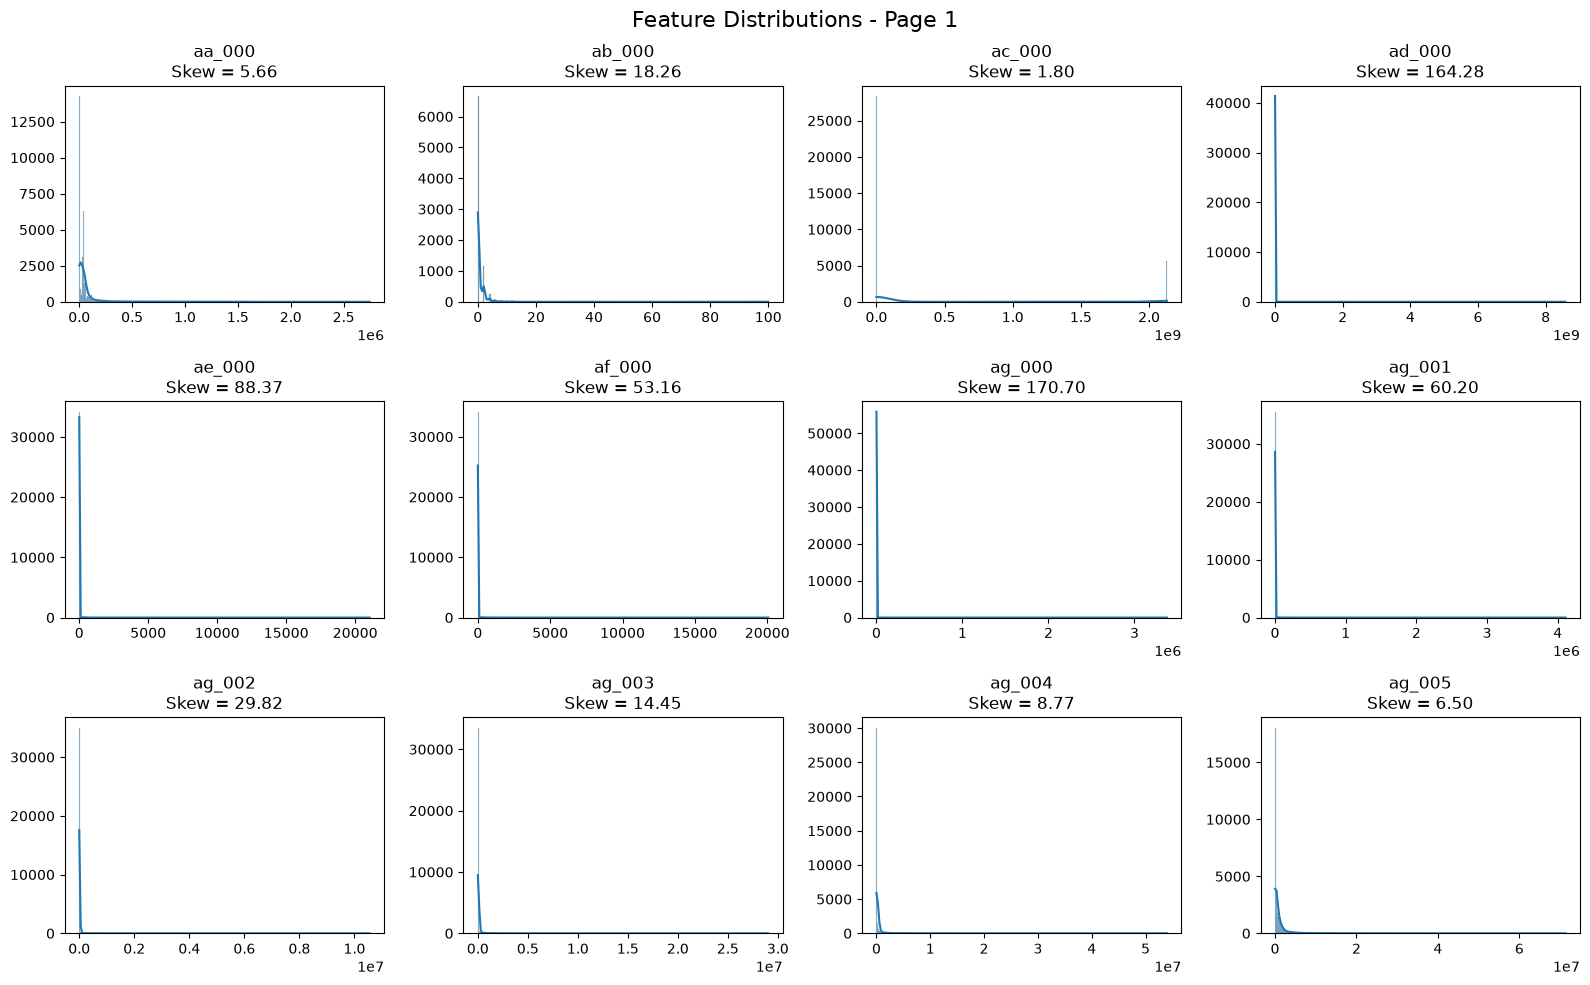

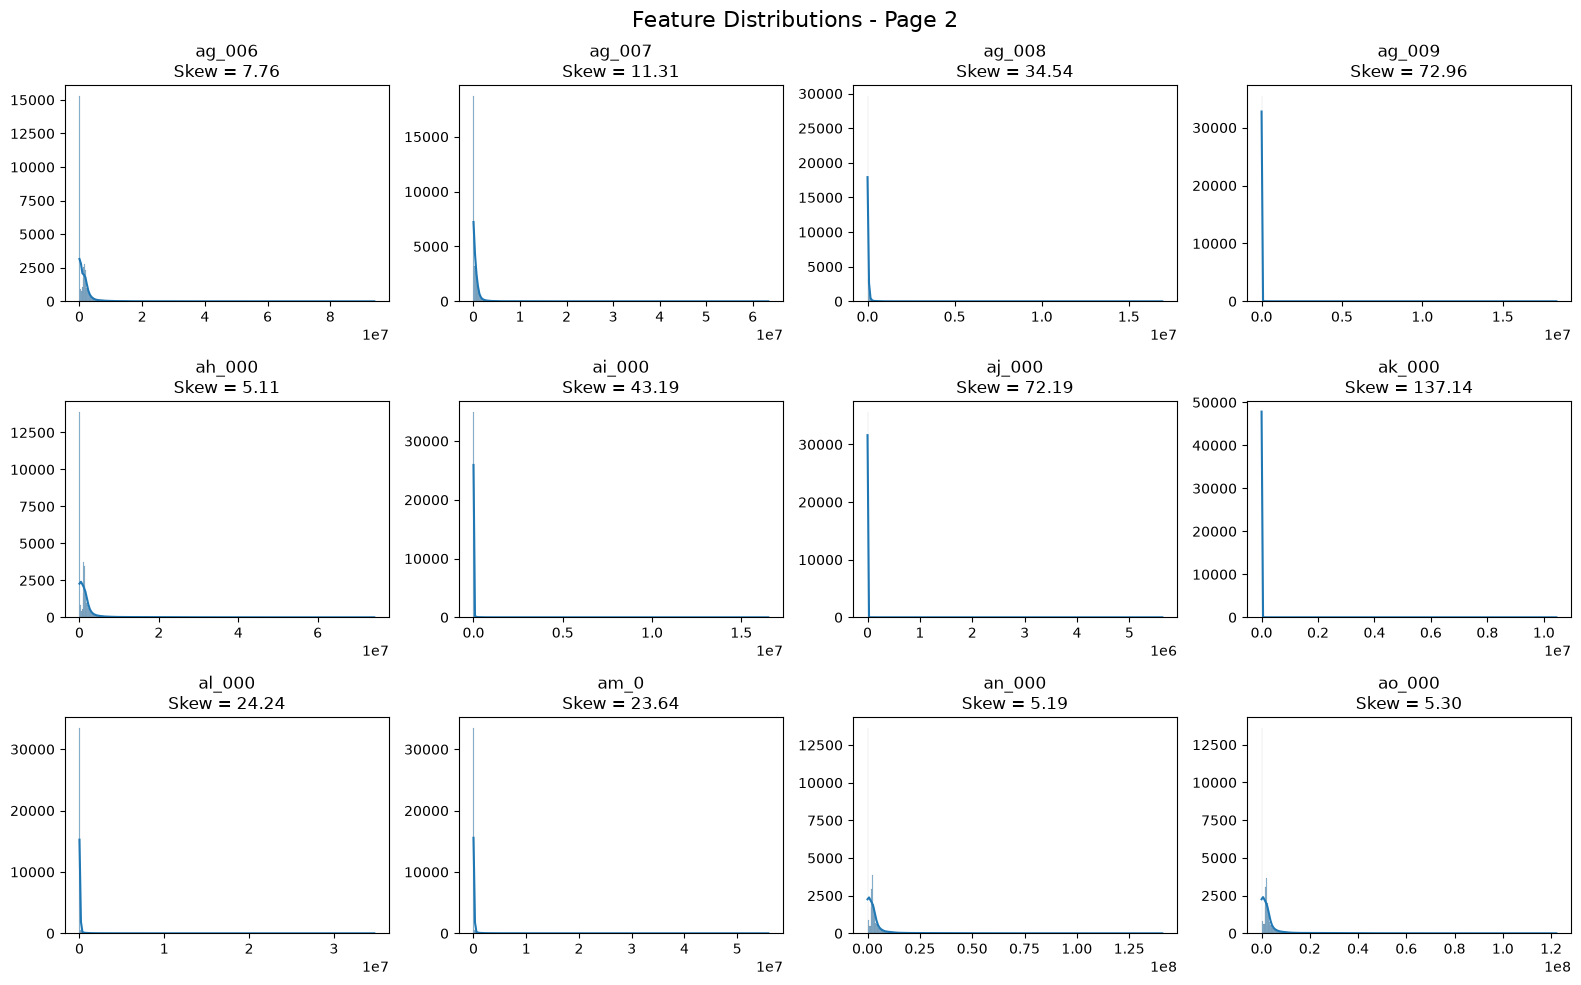

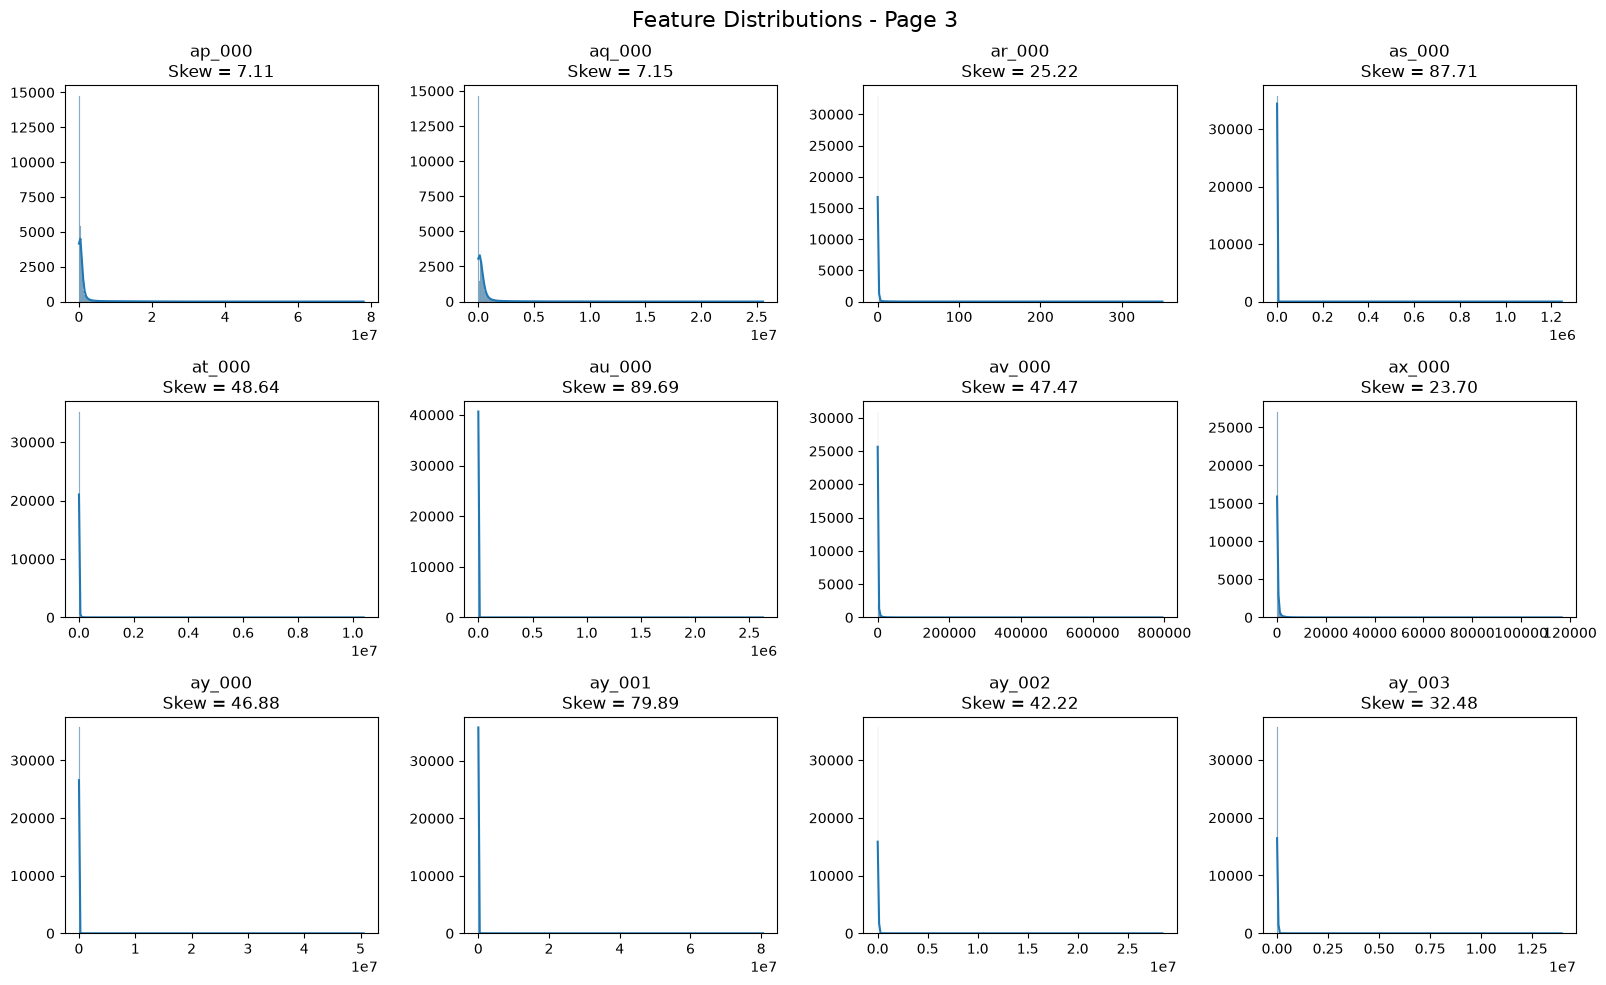

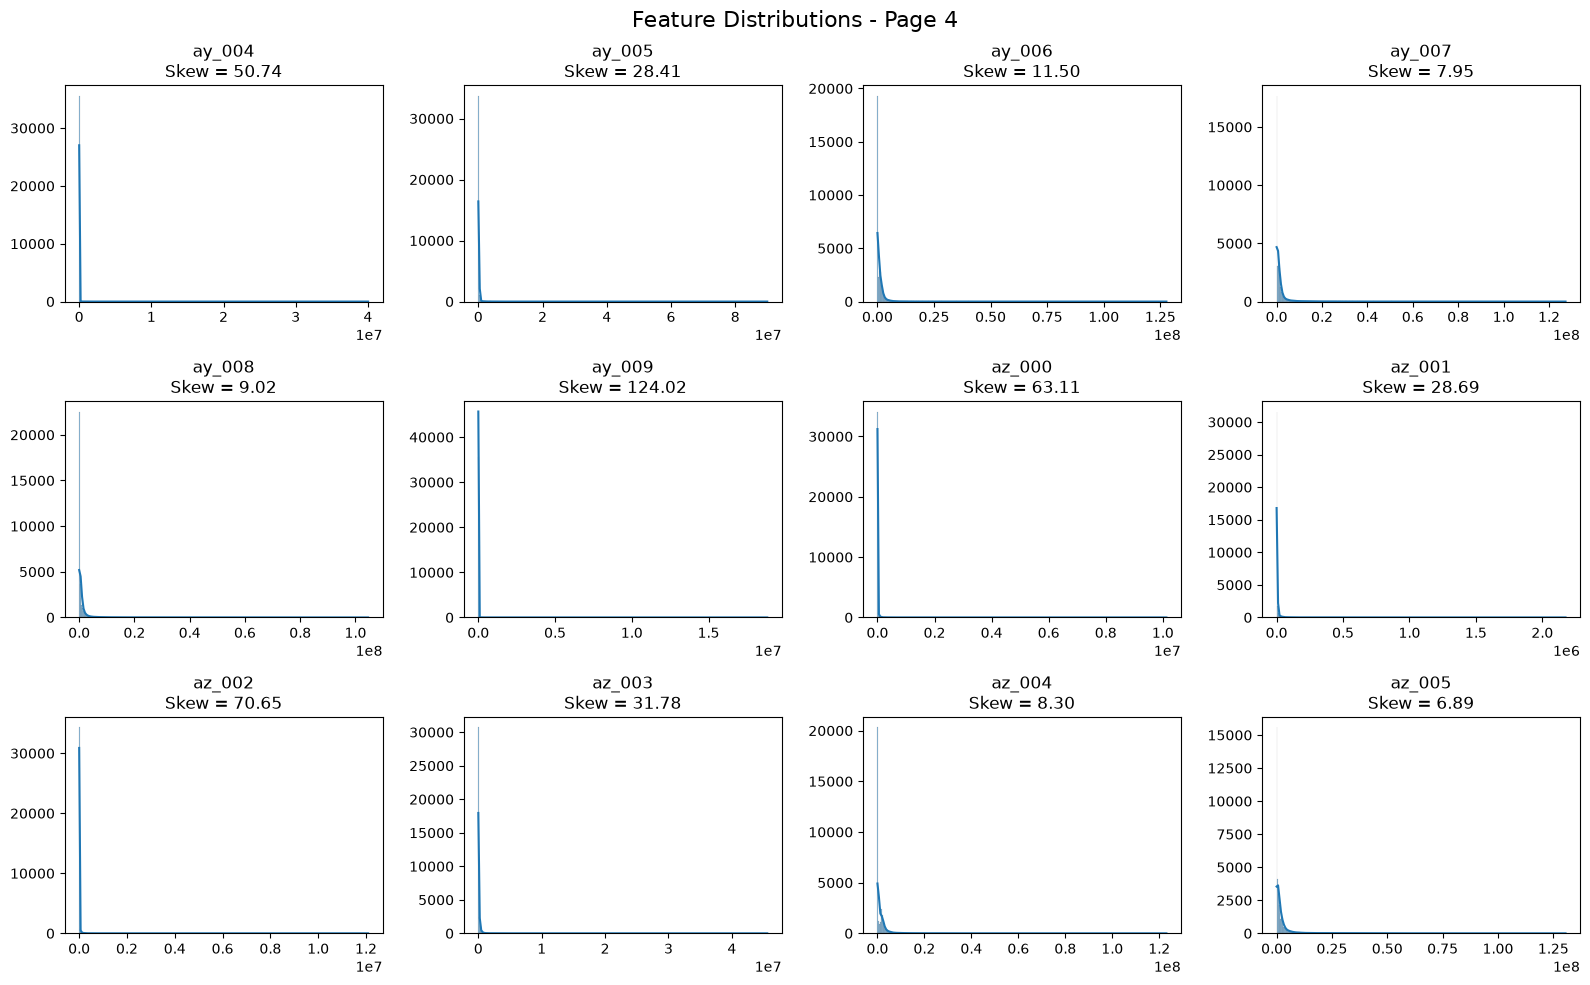

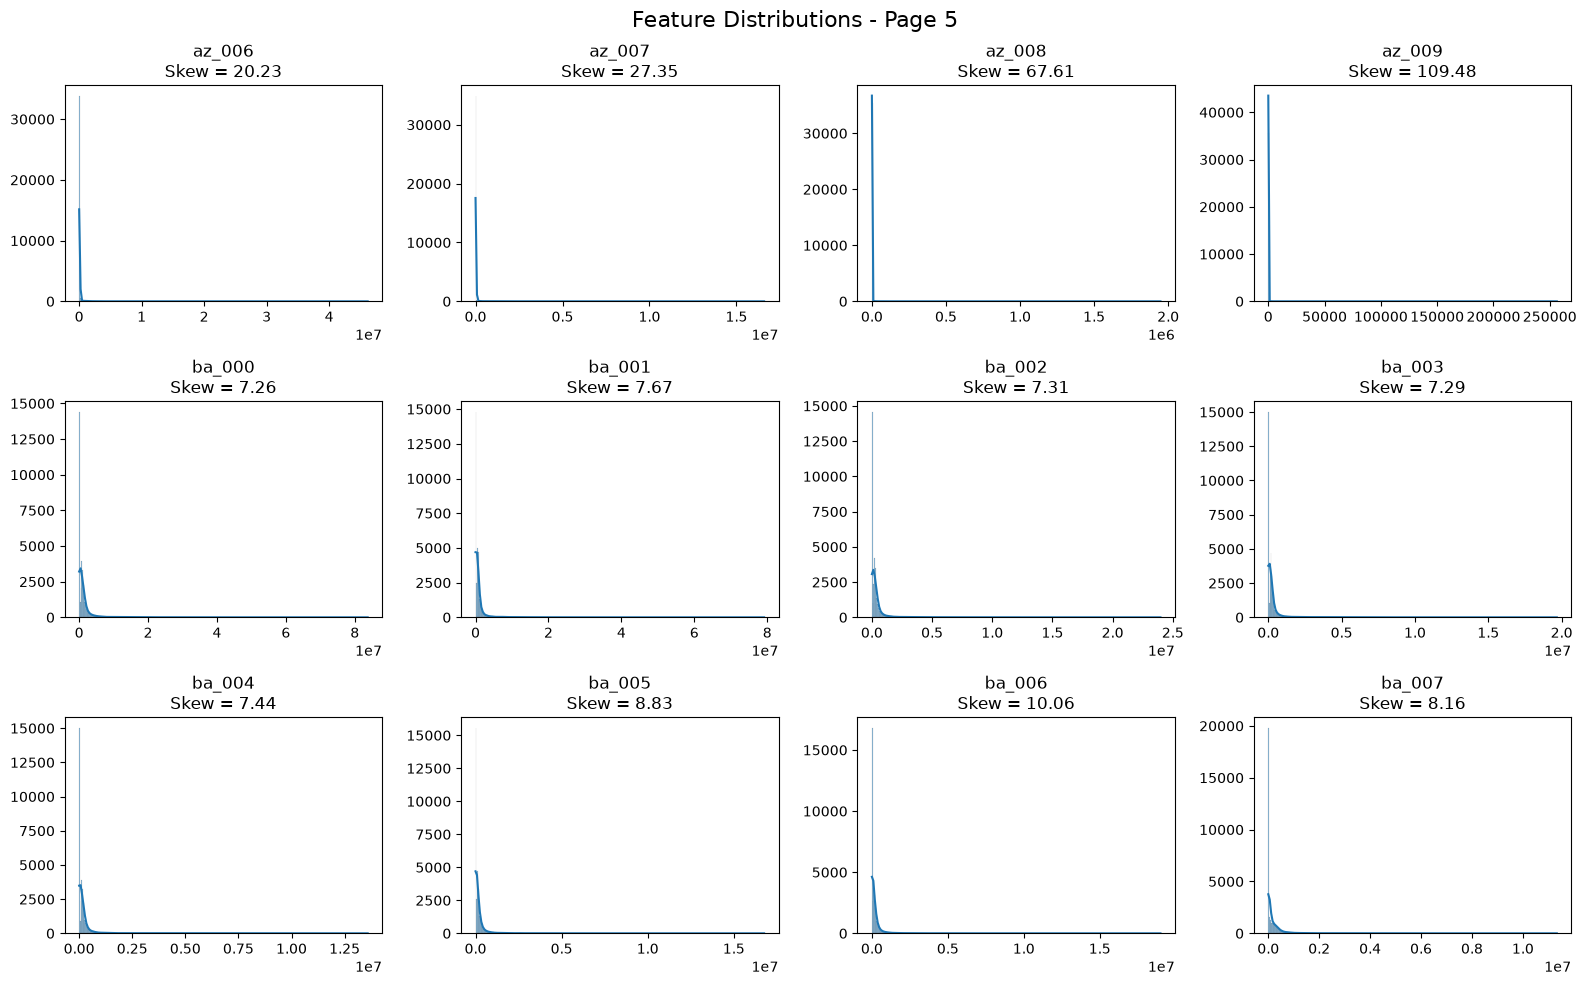

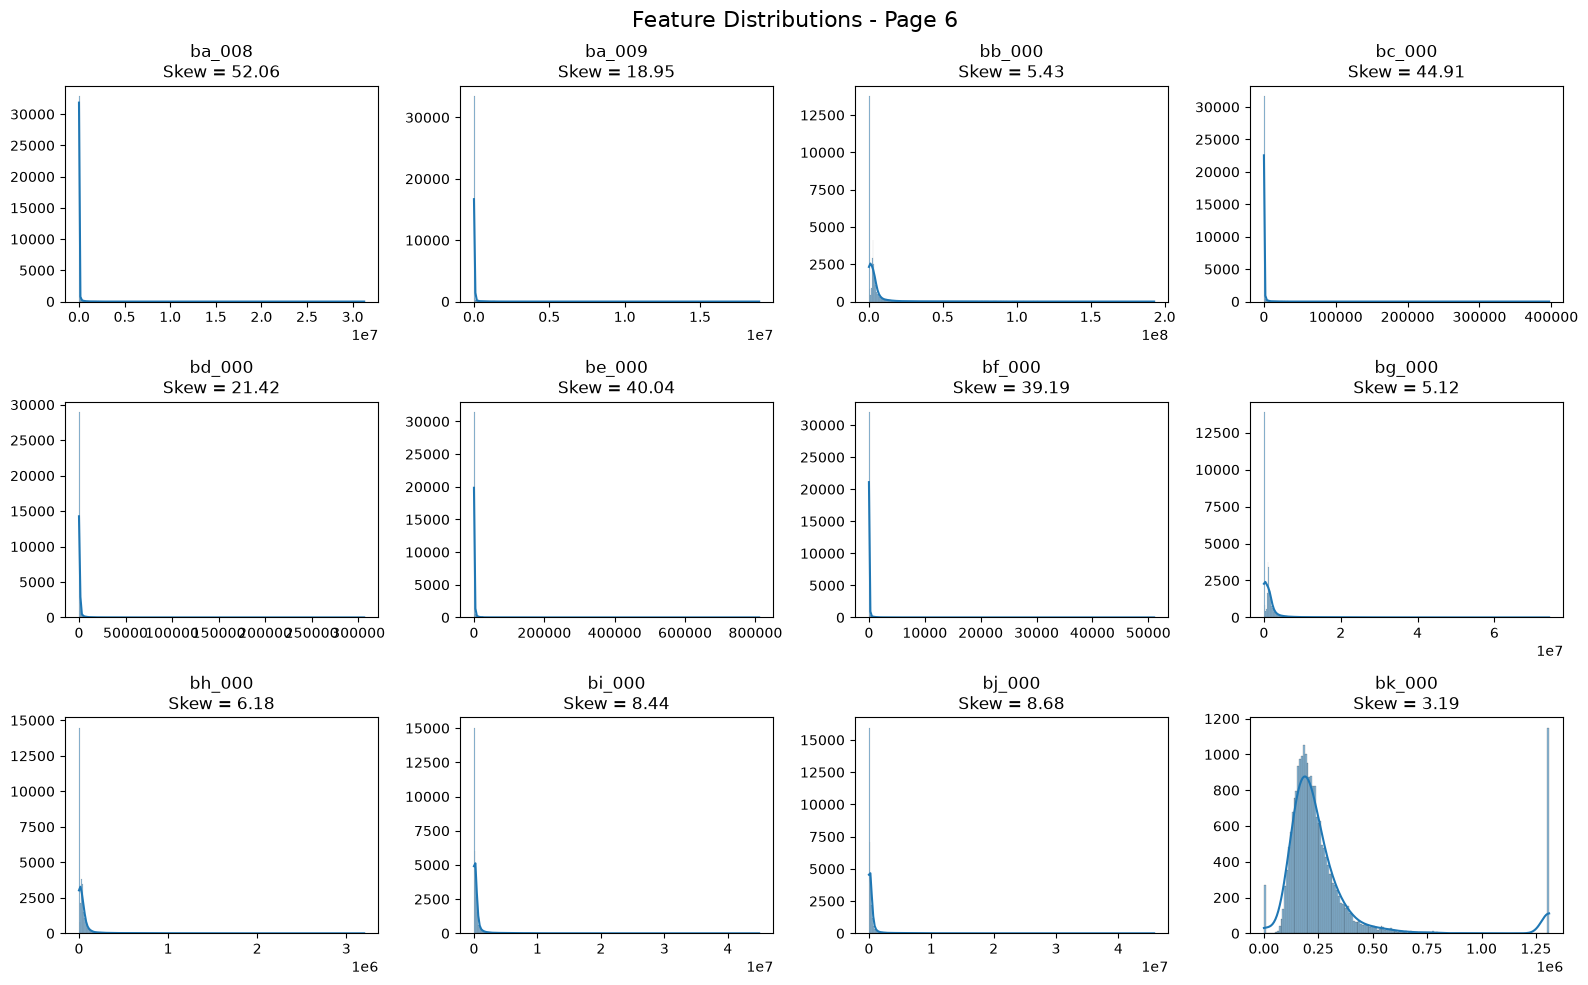

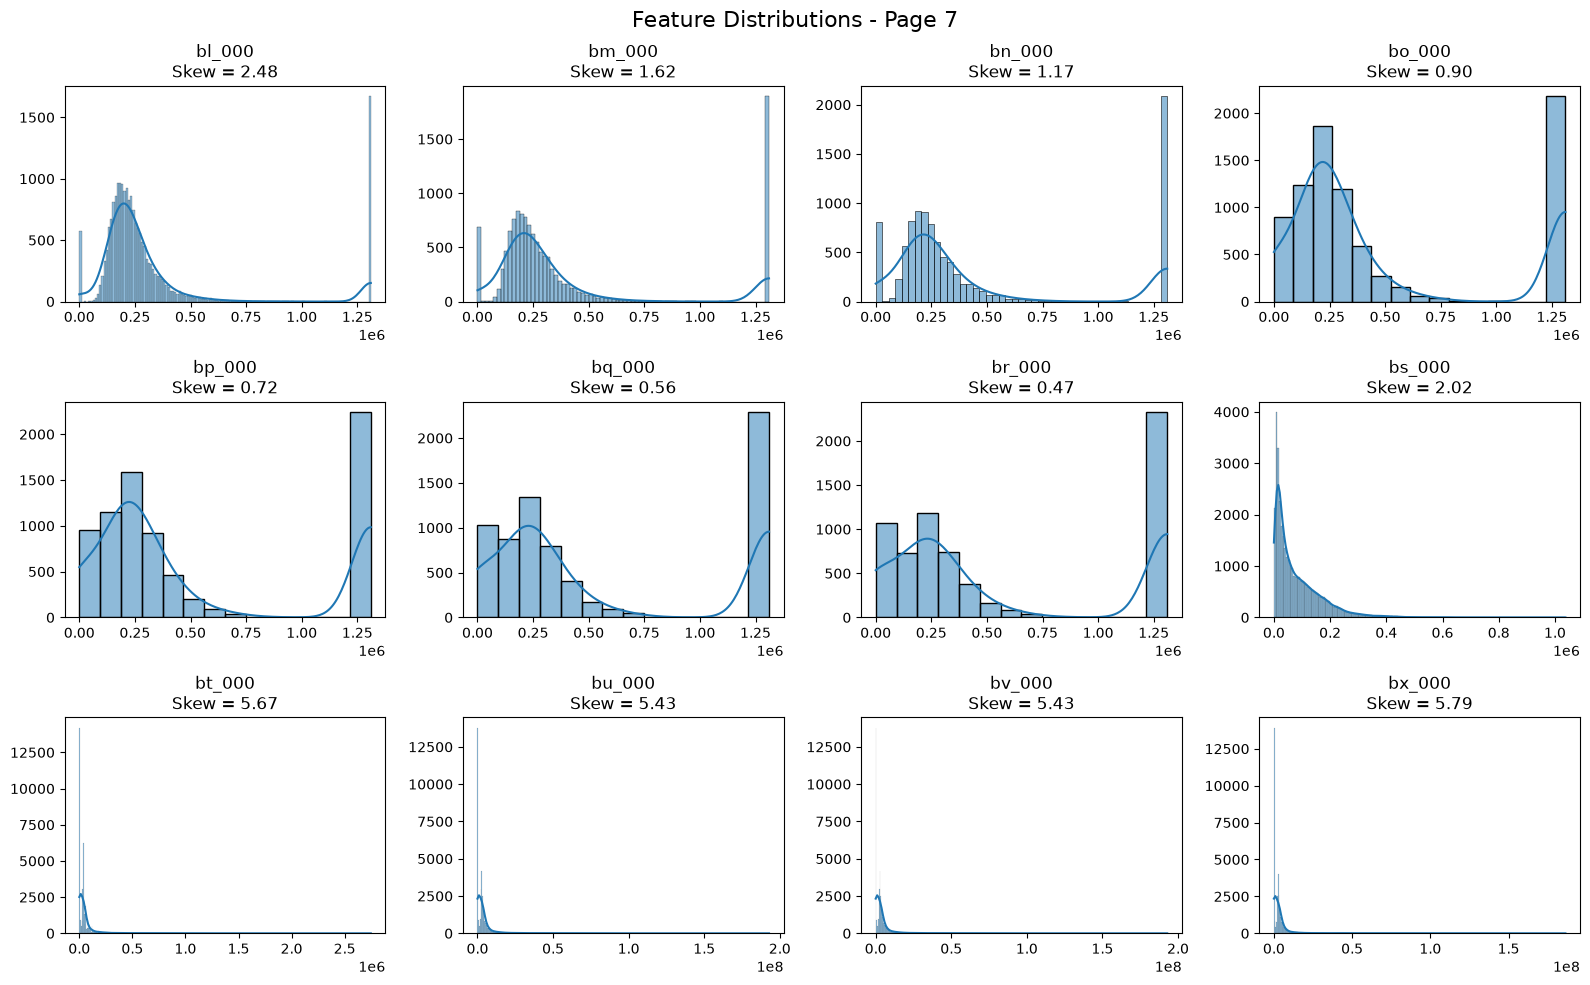

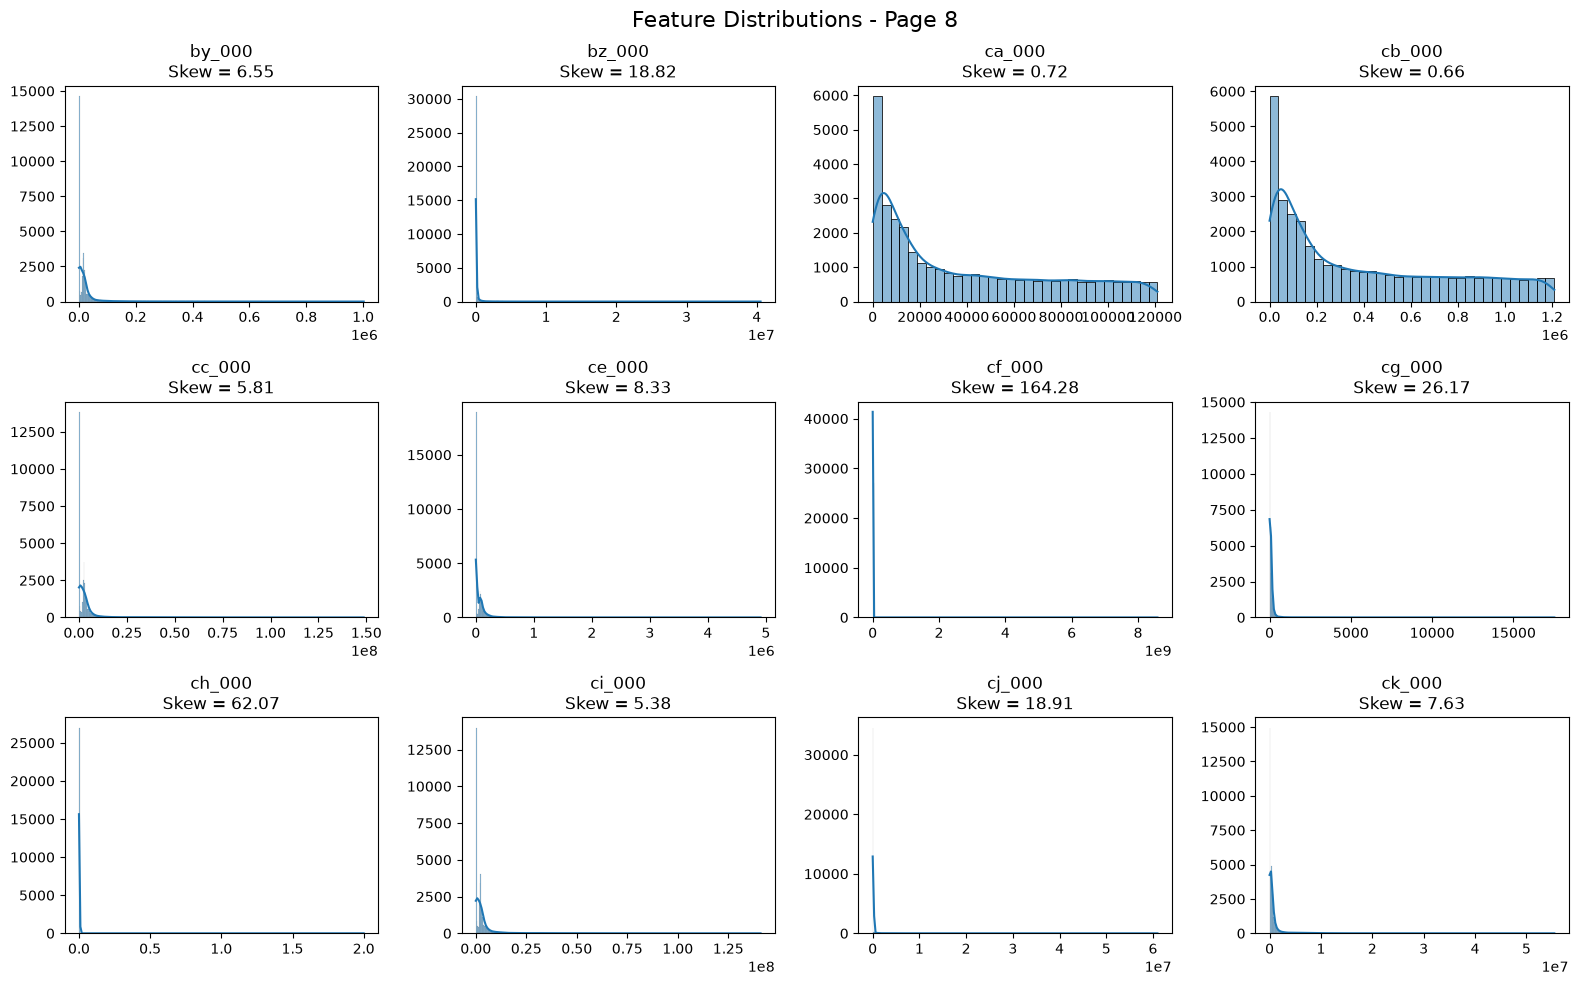

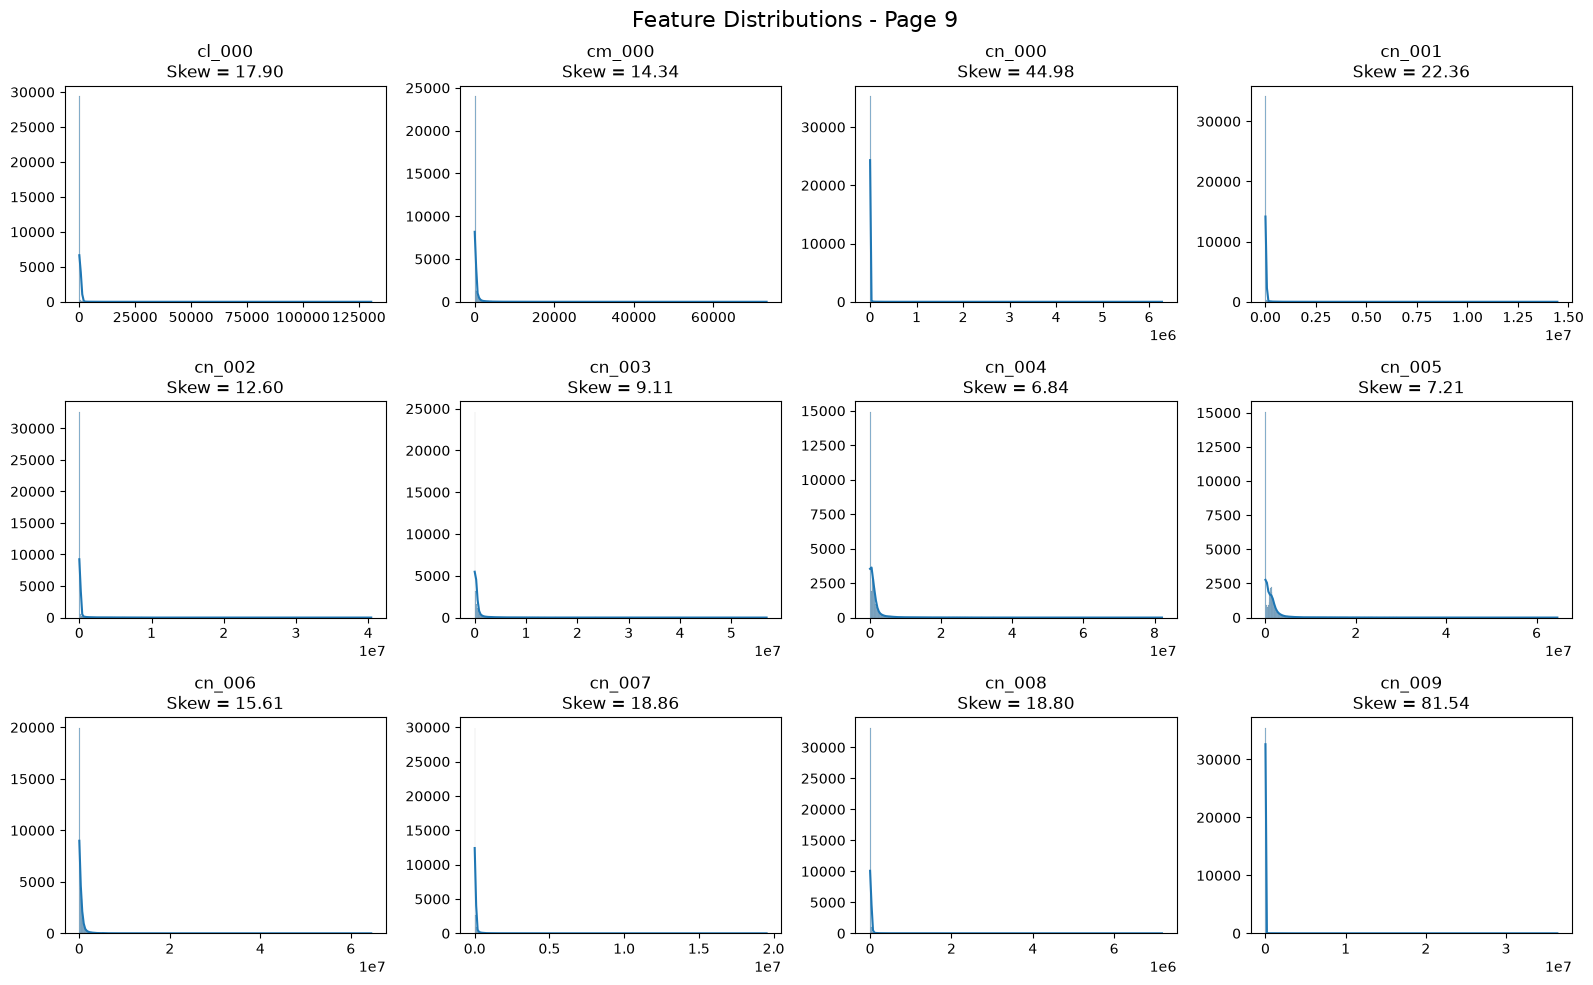

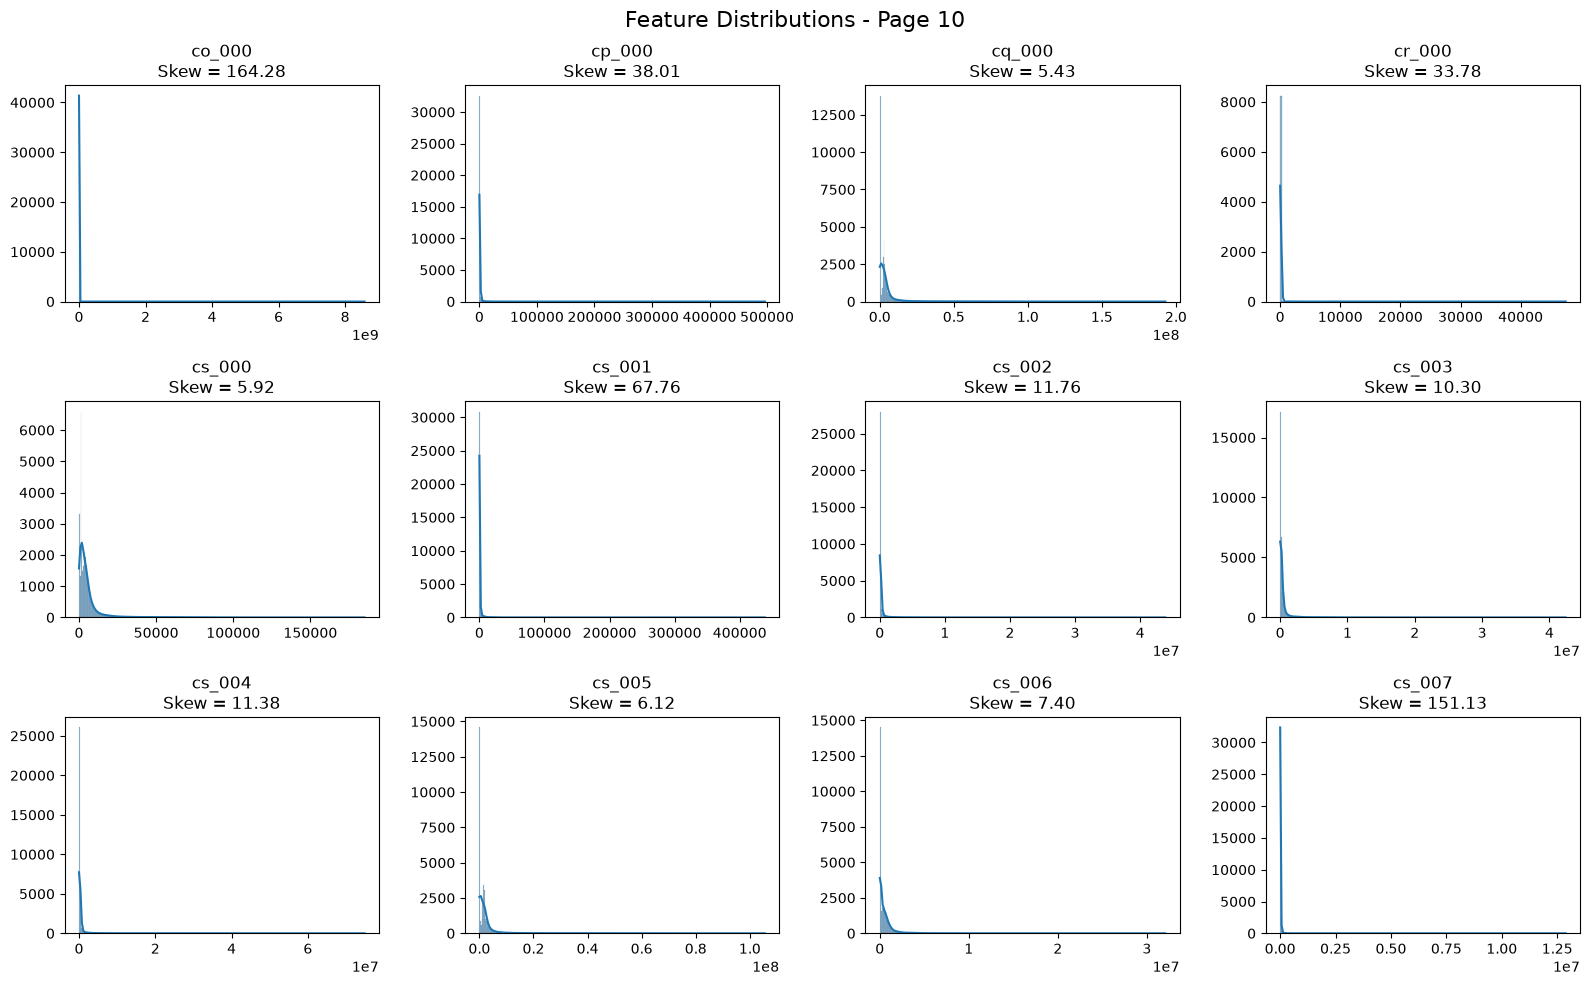

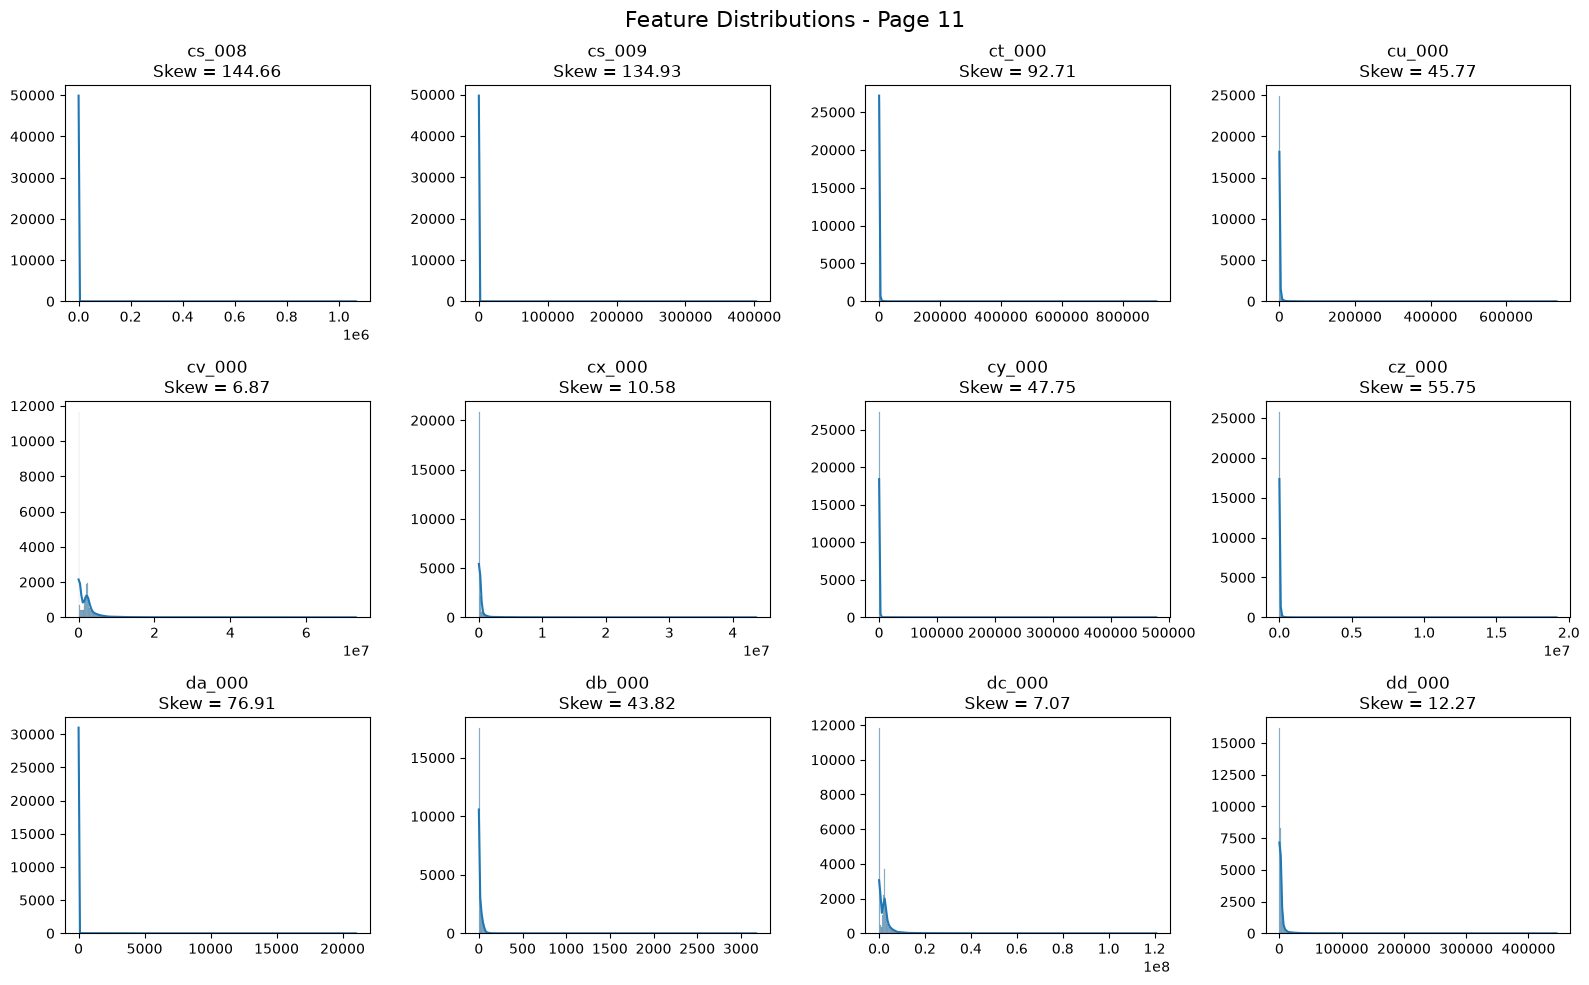

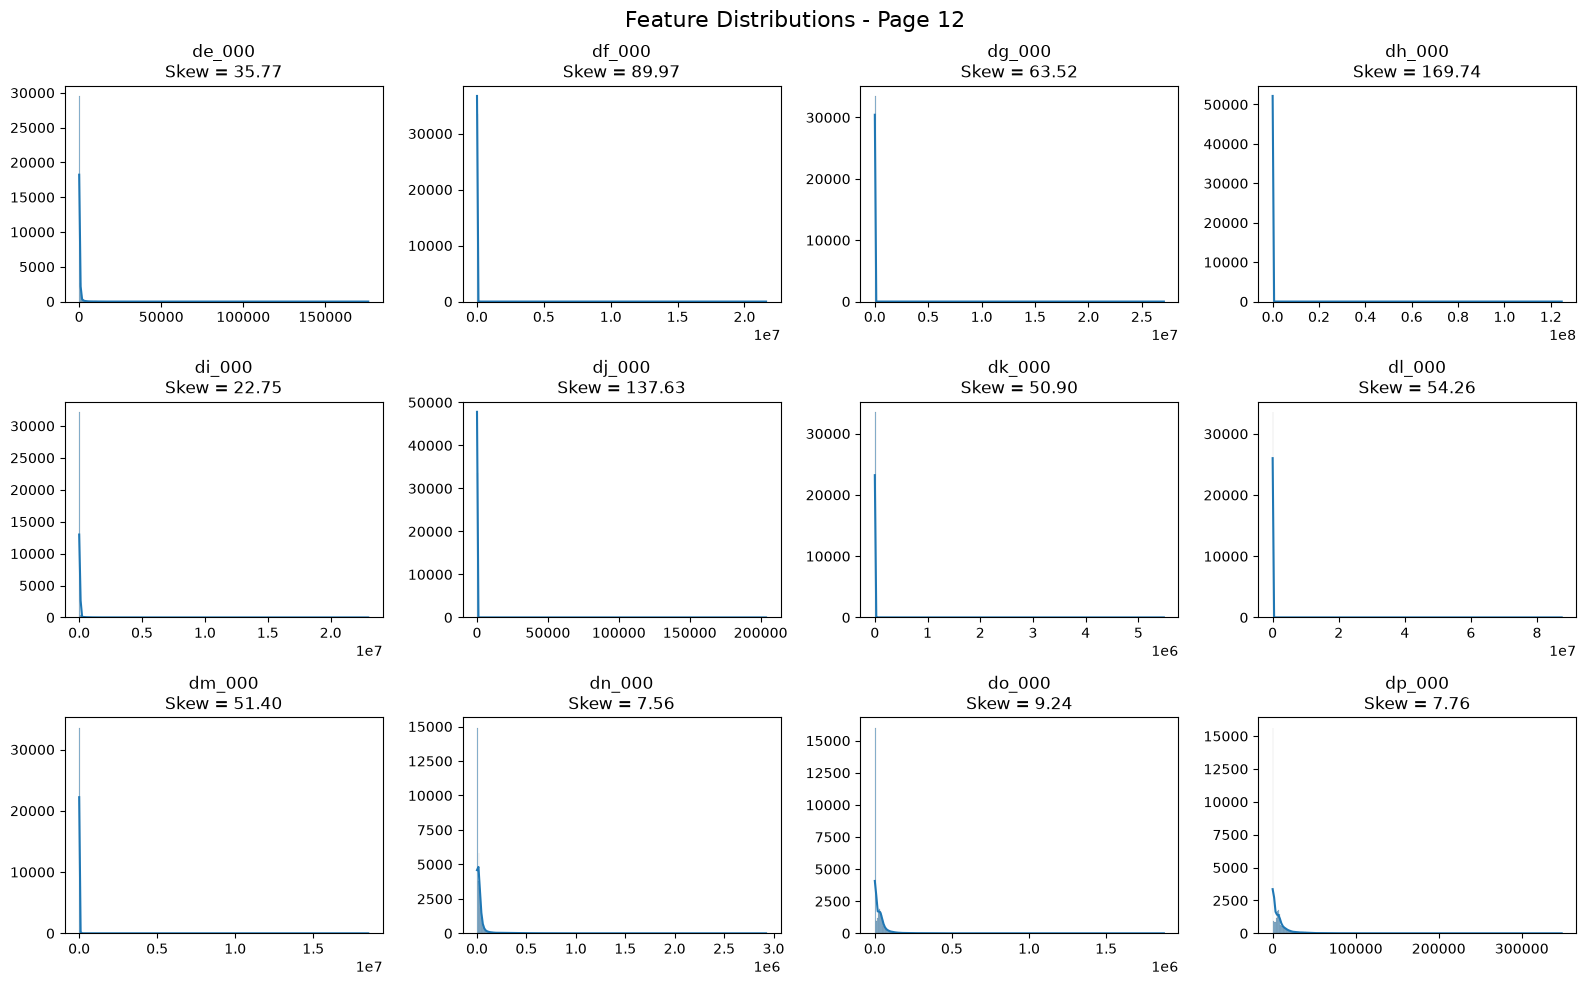

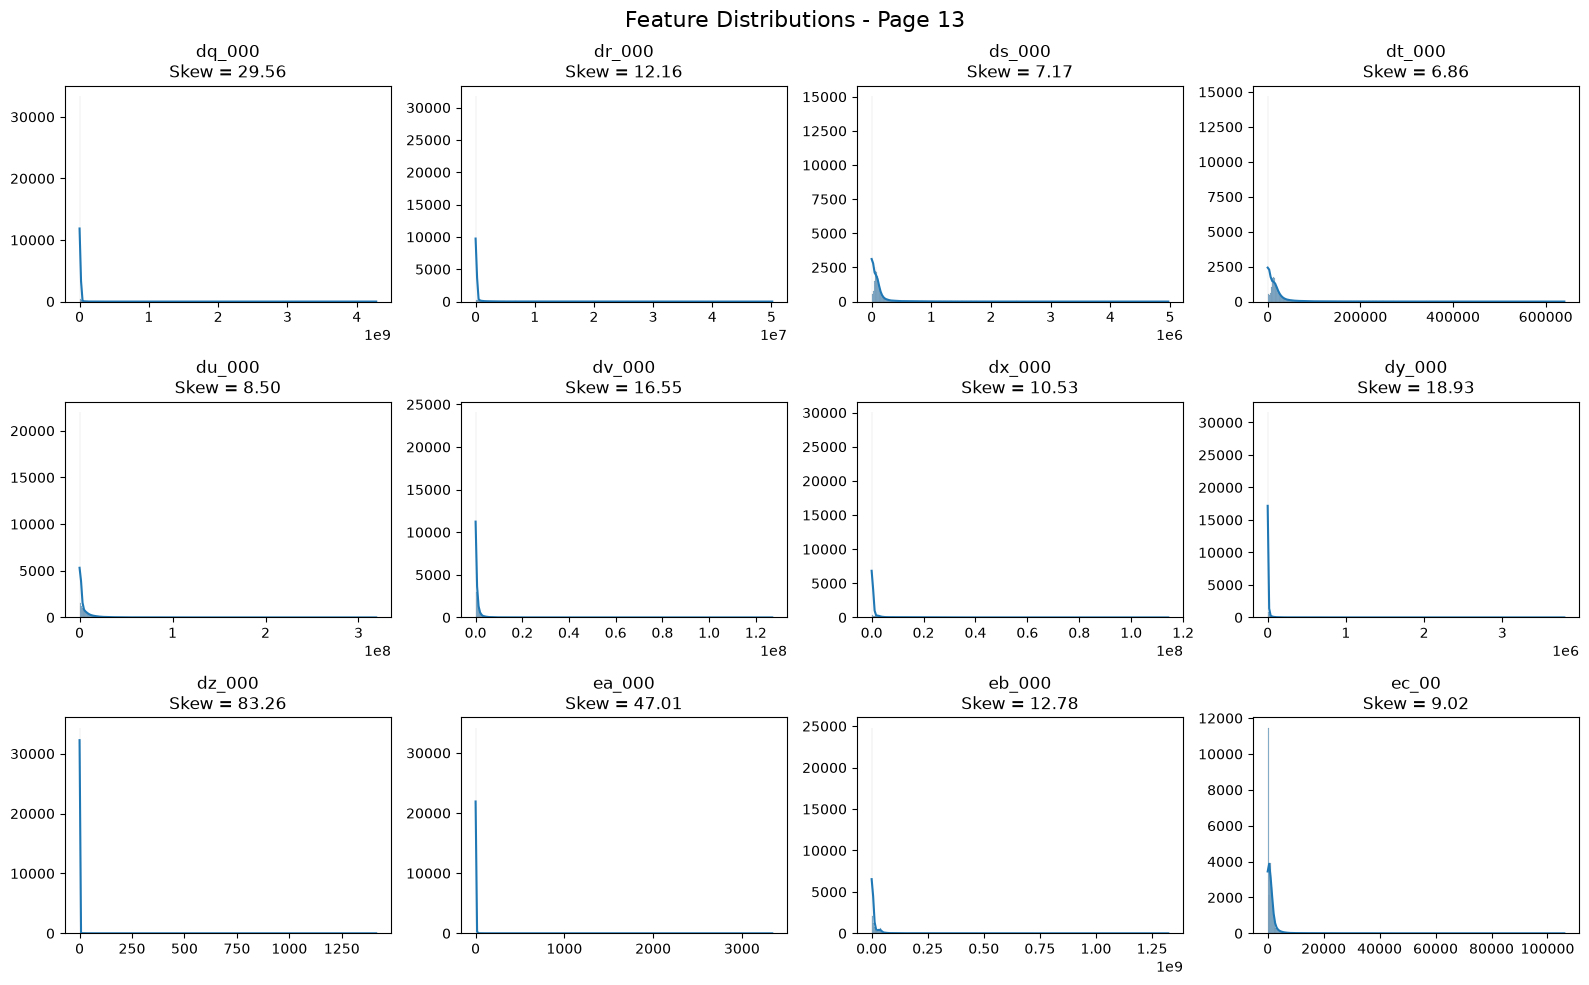

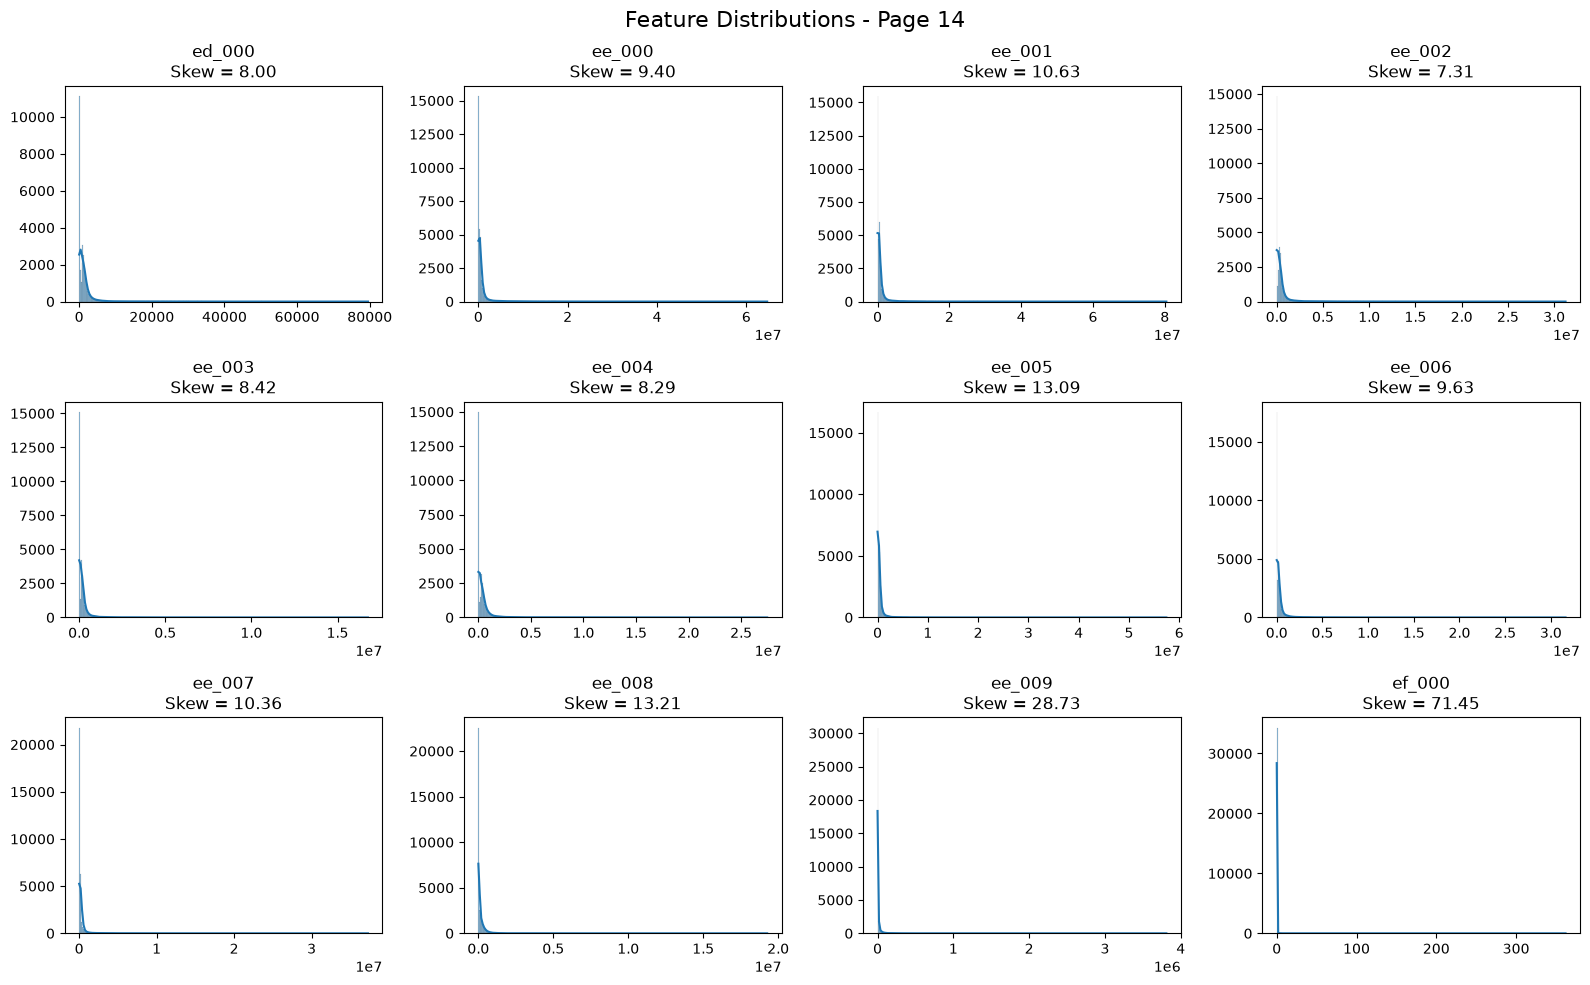

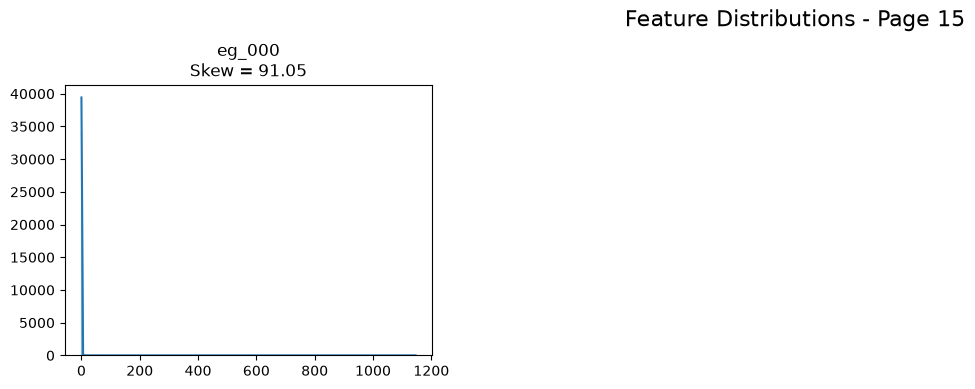

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

features = df.drop(columns=["class"]).select_dtypes(
    include="number"
).columns

features_per_plot = 12

num_plots = math.ceil(len(features) / features_per_plot)

for i in range(num_plots):

    subset = features[
        i * features_per_plot:
        (i + 1) * features_per_plot
    ]

    fig, axes = plt.subplots(
        3, 4,
        figsize=(16, 10)
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, subset):

        sns.histplot(
            df[feature].dropna(),
            kde=True,
            ax=ax
        )

        skew_value = df[feature].skew()

        ax.set_title(
            f"{feature}\nSkew = {skew_value:.2f}"
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

    # Hide unused plots
    for ax in axes[len(subset):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Feature Distributions - Page {i + 1}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

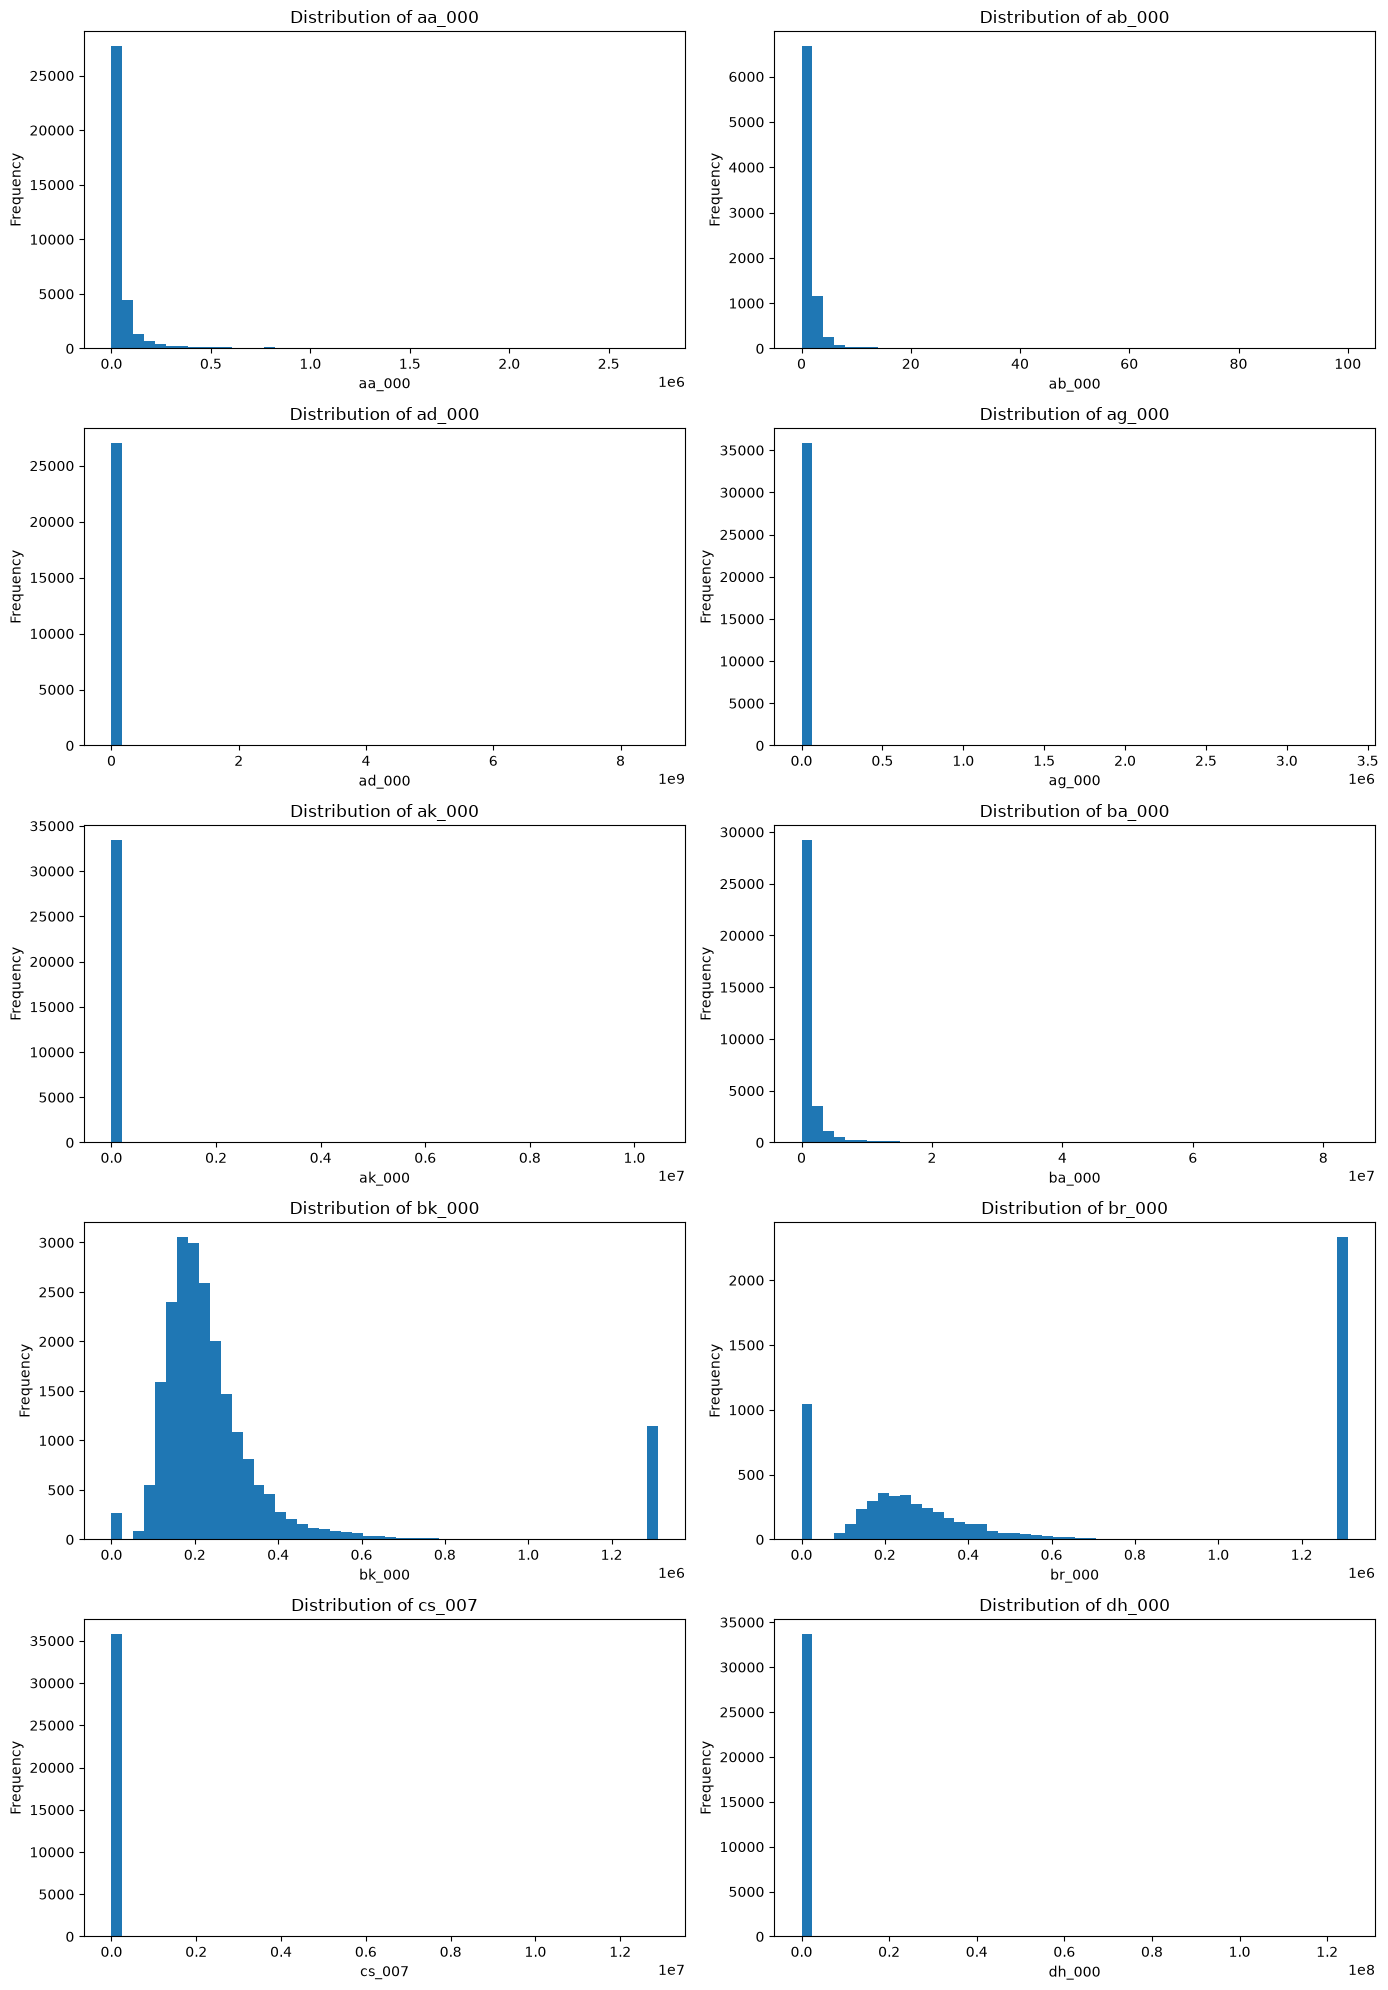

In [75]:
import matplotlib.pyplot as plt

features_to_plot = [
    "aa_000",
    "ab_000",
    "ad_000",
    "ag_000",
    "ak_000",
    "ba_000",
    "bk_000",
    "br_000",
    "cs_007",
    "dh_000"
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 20)
)

for ax, feature in zip(axes.flatten(), features_to_plot):
    ax.hist(df[feature].dropna(), bins=50)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

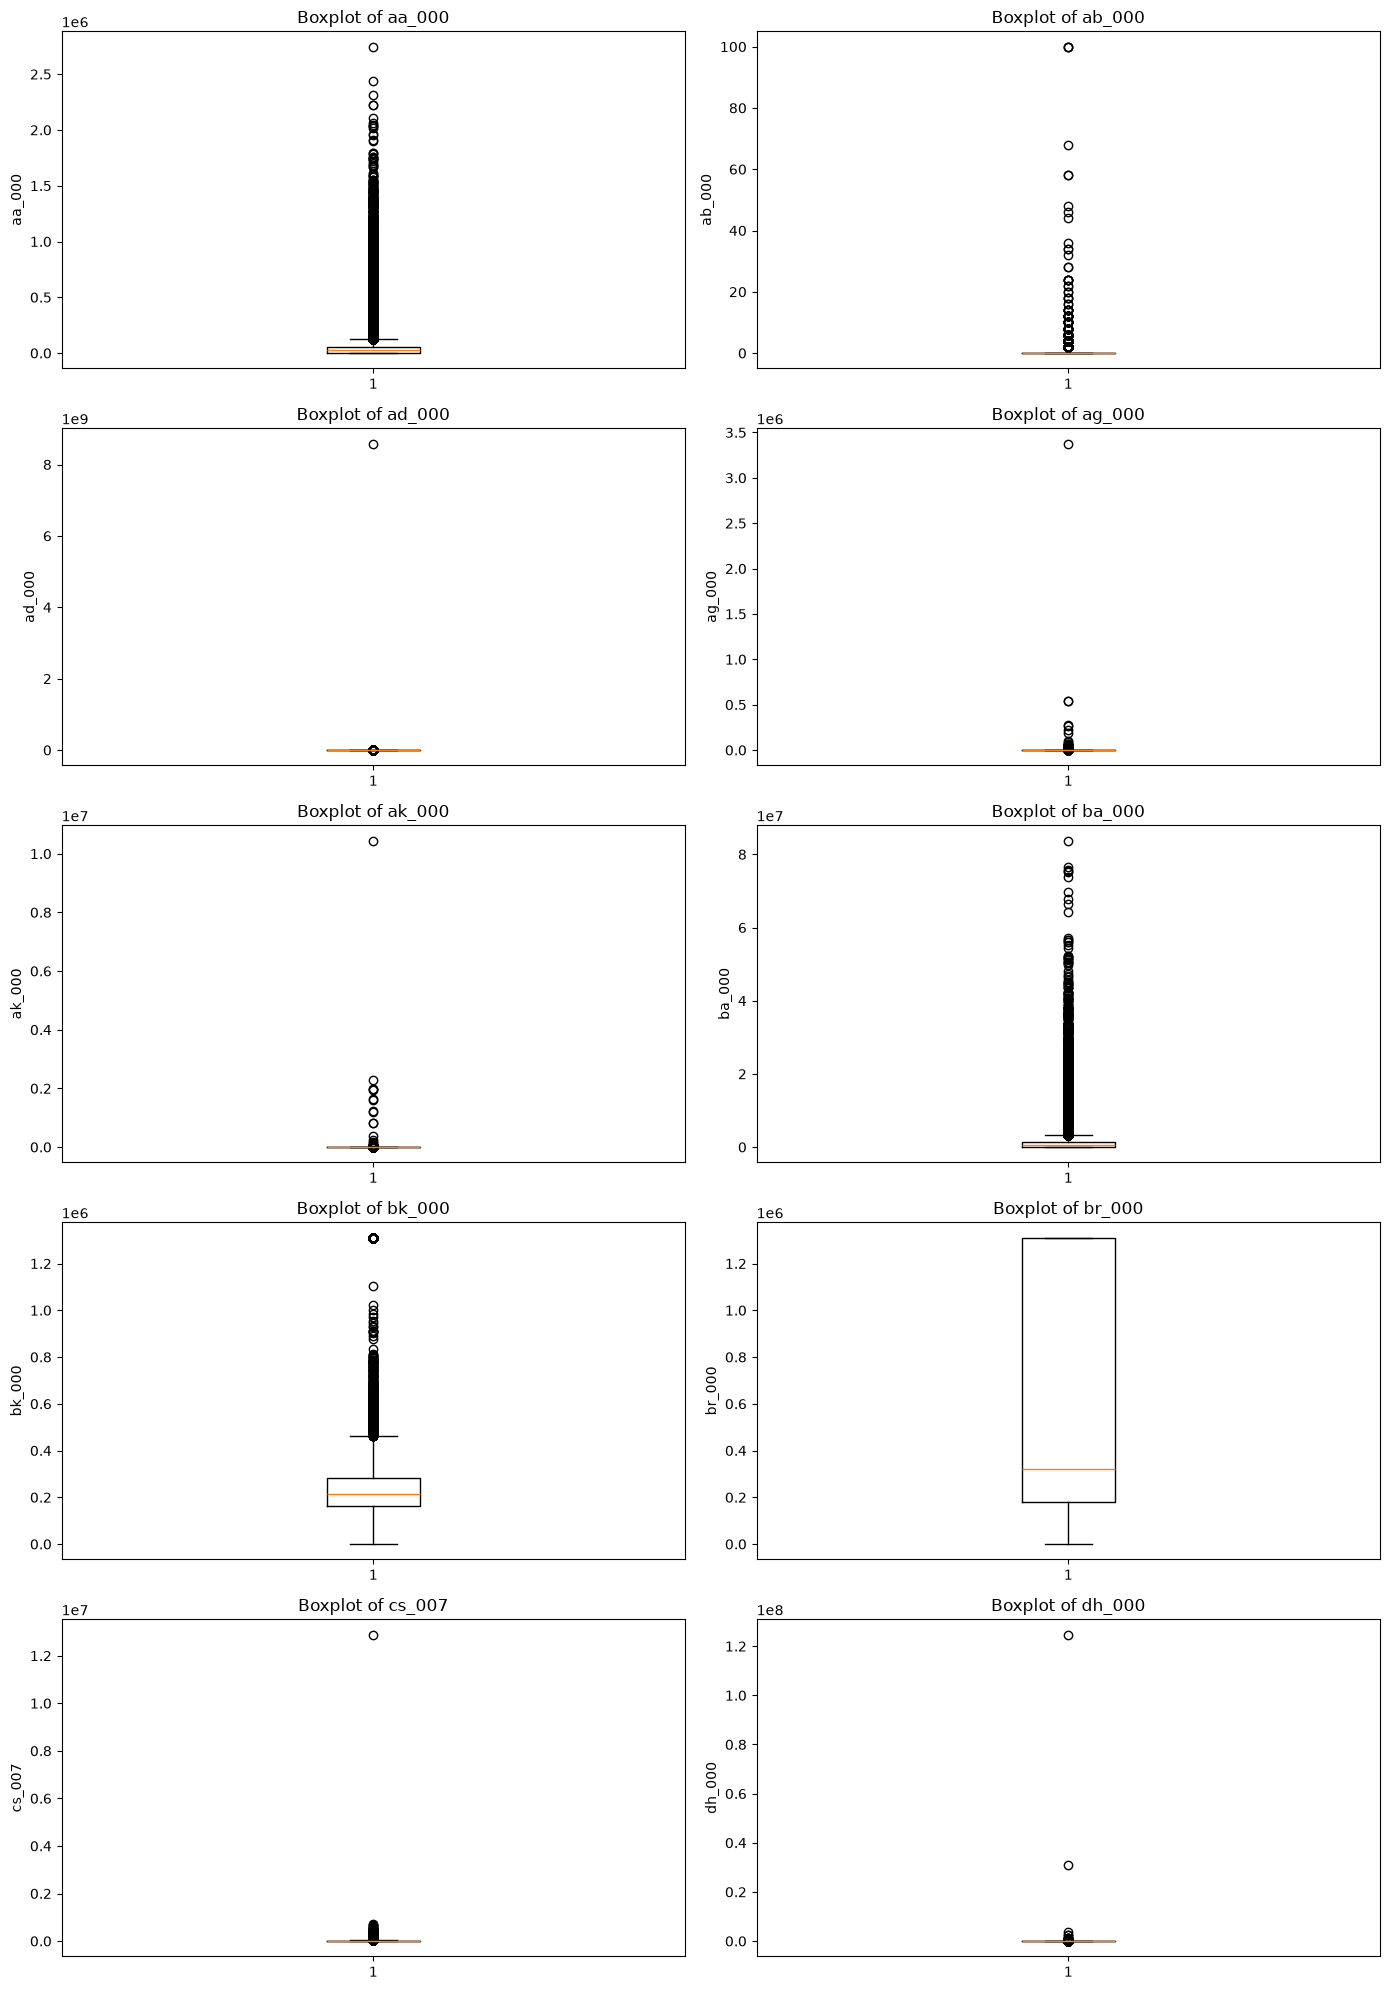

In [76]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 20)
)

for ax, feature in zip(axes.flatten(), features_to_plot):
    ax.boxplot(df[feature].dropna())
    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()